In [1]:
import os, math, random, warnings, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF
from torchvision.transforms import RandomErasing, RandomResizedCrop
import torchvision.models as models
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve
)
import rasterio

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
torch.backends.cudnn.benchmark = True

Using device: cuda


In [2]:
class CFG:
    ROOT          = Path('/kaggle/input/datasets/shreyansdeshpande/200x200/FINALCNNDATA_200')
    OUTPUTDIR     = Path('/kaggle/working')

    TRAINSITE     = ROOT / 'train' / 'site'
    TRAINNOSITE   = ROOT / 'train' / 'no_site'
    VALSITE       = ROOT / 'validation' / 'site'
    VALNOSITE     = ROOT / 'validation' / 'no_site'
    TESTSITE      = ROOT / 'test' / 'site'
    TESTNOSITE    = ROOT / 'test' / 'no_site'

    IMGSUFFIX     = '.tif'
    SATBANDS      = [0, 1, 2, 3]
    LIDARBANDS    = [4, 5, 6, 7, 8, 9, 10]
    INCHANNELS    = len(SATBANDS) + len(LIDARBANDS)

    NUMCLASSES    = 1
    IMGSIZE       = 200
    BATCHSIZE     = 32
    NUMEPOCHS     = 40
    BASELR        = 5e-5
    WEIGHTDECAY   = 0.1
    DROPOUT       = 0.6
    SEED          = 42
    NUMWORKERS    = 2
    USEAMP        = torch.cuda.is_available()

    PATIENCE      = 3
    MINDELTA      = 1e-3
    SCHED_FACTOR  = 0.5
    SCHED_PATIENCE = 2

    USEPOSWEIGHT  = False
    USEFOCALLOSS  = False
    FOCALGAMMA    = 2.0
    LABELSMOOTH   = 0.0

    HEADLRMULT    = 5.0
    LLRD          = 0.8
    FREEZEEPOCHS  = 8
    FREEZESTAGES  = 4

    STOCHDEPTH    = 0.3
    MIXUPPROB     = 0.0
    MIXUPALPHA    = 0.4
    ERASEPROB     = 0.10
    CROPSCALE     = (0.85, 1.0)
    SATNOISESTD   = 0.02
    LIDARNOISESTD = 0.05

    STEMNOISESTD  = 1e-4
    RGBDROPPROB   = 0.30
    LIDARDROPPROB = 0.15
    SAT_SCALE     = 10000.0
    IMAGENET_NORM = True

    LIDARNORM     = 'global'
    LIDARCLIP     = 8.0
    EVALTRAINEACHEPOCH = True

In [3]:
def setseed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

setseed(CFG.SEED)
CFG.OUTPUTDIR.mkdir(parents=True, exist_ok=True)

In [4]:
def foldertodf(sitedir: Path, nositedir: Path) -> pd.DataFrame:
    rows = [{'filepath': str(f), 'label': l}
            for l, d in [(1, sitedir), (0, nositedir)]
            for f in sorted(d.glob(f'*{CFG.IMGSUFFIX}'))]
    return pd.DataFrame(rows)

print('Scanning dataset folders...')
traindf = foldertodf(CFG.TRAINSITE, CFG.TRAINNOSITE)
valdf   = foldertodf(CFG.VALSITE,   CFG.VALNOSITE)
testdf  = foldertodf(CFG.TESTSITE,  CFG.TESTNOSITE)

print(f"Train: {len(traindf)} | Val: {len(valdf)} | Test: {len(testdf)}")
print(f"Train class balance: {traindf['label'].value_counts().to_dict()}")

Scanning dataset folders...
Train: 3596 | Val: 1245 | Test: 878
Train class balance: {0: 2720, 1: 876}


In [5]:
def loadrawpatch(tifpath: str):
    with rasterio.open(tifpath) as src:
        img = src.read(masked=True).astype(np.float32).filled(0.0)
    sat = img[CFG.SATBANDS] / CFG.SAT_SCALE
    sat = np.clip(sat, 0.0, 1.0)
    return sat, img[CFG.LIDARBANDS]


def buildrawcache(df: pd.DataFrame, splitname: str):
    print(f"Caching {len(df)} {splitname} patches into RAM...")
    sats, lidars, labels = [], [], []
    for row in df.itertuples():
        s, l = loadrawpatch(row.filepath)
        sats.append(s); lidars.append(l); labels.append(float(row.label))
    return sats, lidars, labels


def computelidarstats(lidars):
    n = len(CFG.LIDARBANDS)
    total = np.zeros(n, np.float64)
    totalsq = np.zeros(n, np.float64)
    count = 0
    for l in lidars:
        ld = l.astype(np.float64)
        total   += ld.sum(axis=(1, 2))
        totalsq += (ld ** 2).sum(axis=(1, 2))
        count   += l.shape[1] * l.shape[2]
    mean = total / count
    var = np.maximum(totalsq / count - mean ** 2, 1e-12)
    return mean.astype(np.float32), np.sqrt(var).astype(np.float32)


def normalizelidarperpatch(arr: np.ndarray) -> np.ndarray:
    out = np.empty_like(arr, dtype=np.float32)
    for c, ch in enumerate(arr):
        mean, std = float(np.nanmean(ch)), float(np.nanstd(ch))
        out[c] = ch - mean if std < 1e-4 or np.isnan(std) else (ch - mean) / (std + 1e-6)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


def finalizecache(sats, lidars, labels, lmean, lstd):
    out = []
    for i in range(len(sats)):
        l = lidars[i]
        if CFG.LIDARNORM == 'global':
            ln = (l - lmean[:, None, None]) / (lstd[:, None, None] + 1e-6)
            ln = np.clip(ln, -CFG.LIDARCLIP, CFG.LIDARCLIP)
        else:
            ln = normalizelidarperpatch(l)
        ln = np.nan_to_num(ln, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        out.append((np.concatenate([sats[i], ln], axis=0), labels[i]))
        sats[i] = None; lidars[i] = None
    return out

In [6]:
class MultiModalDataset(Dataset):
    def __init__(self, cached, istrain: bool = True):
        self.cached = cached
        self.istrain = istrain
        self.randomerase = RandomErasing(p=CFG.ERASEPROB, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0.0)
        self.randomcrop = RandomResizedCrop(CFG.IMGSIZE, scale=CFG.CROPSCALE, ratio=(0.85, 1.18), antialias=True)
        self.rgb_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.rgb_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.cached)

    def __getitem__(self, idx):
        img, label = self.cached[idx]
        t = torch.from_numpy(img).clone()
        nsat = len(CFG.SATBANDS)

        if CFG.IMAGENET_NORM and nsat >= 3:
            t[:3] = (t[:3] - self.rgb_mean) / self.rgb_std

        if self.istrain:
            t = self.randomcrop(t)
            if random.random() > 0.5: t = TF.hflip(t)
            if random.random() > 0.5: t = TF.vflip(t)
            k = random.choice([0, 1, 2, 3])
            if k: t = torch.rot90(t, k, dims=(1, 2))

            if random.random() > 0.5:
                t[:nsat] += torch.randn_like(t[:nsat]) * CFG.SATNOISESTD
                t[nsat:] += torch.randn_like(t[nsat:]) * CFG.LIDARNOISESTD

            t = self.randomerase(t)

            if random.random() < CFG.RGBDROPPROB:
                satmean = t[0:nsat].mean(dim=(1, 2), keepdim=True)
                t[0:nsat] = satmean.expand_as(t[0:nsat])
            if random.random() < CFG.LIDARDROPPROB:
                t[nsat:] = 0.0
        else:
            if t.shape[-1] != CFG.IMGSIZE or t.shape[-2] != CFG.IMGSIZE:
                t = TF.resize(t, [CFG.IMGSIZE, CFG.IMGSIZE],
                              interpolation=TF.InterpolationMode.BILINEAR, antialias=True)

        return t, torch.tensor(label, dtype=torch.float32)

In [7]:
trnsats, trnlidars, trnlabels_raw = buildrawcache(traindf, "Train")
LIDARMEAN, LIDARSTD = computelidarstats(trnlidars)
print(f"LiDAR channel means: {np.round(LIDARMEAN, 3)}")
print(f"LiDAR channel stds : {np.round(LIDARSTD, 3)}")

traincache = finalizecache(trnsats, trnlidars, trnlabels_raw, LIDARMEAN, LIDARSTD)
del trnsats, trnlidars; gc.collect()

vs, vl, vlab = buildrawcache(valdf, "Val")
valcache = finalizecache(vs, vl, vlab, LIDARMEAN, LIDARSTD)
del vs, vl; gc.collect()

ts, tl, tlab = buildrawcache(testdf, "Test")
testcache = finalizecache(ts, tl, tlab, LIDARMEAN, LIDARSTD)
del ts, tl; gc.collect()

Caching 3596 Train patches into RAM...
LiDAR channel means: [0.026 7.547 0.928 0.631 0.627 0.632 0.637]
LiDAR channel stds : [1.167 6.61  0.063 0.094 0.102 0.094 0.101]
Caching 1245 Val patches into RAM...
Caching 878 Test patches into RAM...


30

In [8]:
counts = traindf['label'].value_counts().to_dict()
sampleweights = [1.0 / counts[lbl] for lbl in traindf['label']]
sampler = WeightedRandomSampler(weights=sampleweights, num_samples=len(traindf), replacement=True)

trnloader      = DataLoader(MultiModalDataset(traincache, True),  batch_size=CFG.BATCHSIZE,
                            sampler=sampler, num_workers=CFG.NUMWORKERS, pin_memory=True, drop_last=True)
trnloader_eval = DataLoader(MultiModalDataset(traincache, False), batch_size=CFG.BATCHSIZE * 2,
                            shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
valloader      = DataLoader(MultiModalDataset(valcache, False),    batch_size=CFG.BATCHSIZE * 2,
                            shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
testloader     = DataLoader(MultiModalDataset(testcache, False),   batch_size=CFG.BATCHSIZE * 2,
                            shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)

In [9]:
def createconvnextmodel(inchannels=11, numclasses=1, dropout=CFG.DROPOUT):
    model = models.convnext_tiny(
        weights=models.ConvNeXt_Tiny_Weights.DEFAULT,
        stochastic_depth_prob=CFG.STOCHDEPTH,
    )

    oldconv = model.features[0][0]
    oldinchannels  = oldconv.weight.shape[1]
    oldoutchannels = oldconv.out_channels

    newconv = nn.Conv2d(
        in_channels=inchannels,
        out_channels=oldoutchannels,
        kernel_size=oldconv.kernel_size,
        stride=oldconv.stride,
        padding=oldconv.padding,
        bias=oldconv.bias is not None,
    )

    with torch.no_grad():
        if inchannels == oldinchannels:
            newconv.weight[:] = oldconv.weight
        elif oldinchannels == 3 and inchannels > 3:
            newconv.weight[:, 0:3, :, :] = oldconv.weight
            meanweight = oldconv.weight.mean(dim=1)
            for c in range(3, inchannels):
                newconv.weight[:, c, :, :] = meanweight * 0.25
            newconv.weight[:, 3:inchannels, :, :] *= (oldinchannels / inchannels)
            newconv.weight[:, 3:inchannels, :, :] += torch.randn_like(
                newconv.weight[:, 3:inchannels, :, :]) * CFG.STEMNOISESTD
        else:
            nn.init.kaiming_normal_(newconv.weight, nonlinearity='relu')

        if oldconv.bias is not None:
            newconv.bias.copy_(oldconv.bias)

    model.features[0][0] = newconv
    infeatures = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        nn.Dropout(p=dropout),
        nn.Linear(infeatures, numclasses),
    )
    return model

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        ptcorrect = torch.where(targets >= 0.5, probs, 1 - probs)
        focalterm = (1 - ptcorrect).clamp(min=1e-6).pow(self.gamma)
        loss = focalterm * bce
        if self.pos_weight is not None:
            alphaweight = torch.where(targets >= 0.5, self.pos_weight, torch.ones_like(targets))
            loss = loss * alphaweight
        return loss.mean()

posweighttensor = None
if CFG.USEPOSWEIGHT:
    posweighttensor = torch.tensor([counts.get(0, 0) / max(counts.get(1, 1), 1)],
                                   dtype=torch.float32).to(DEVICE)

criterion = (FocalLoss(gamma=CFG.FOCALGAMMA, pos_weight=posweighttensor)
             if CFG.USEFOCALLOSS else nn.BCEWithLogitsLoss(pos_weight=posweighttensor))

In [11]:
def ishead(name: str) -> bool:
    return name.startswith('features.0.0') or name.startswith('features.0.1') or name.startswith('classifier')

def stagedepth(name: str) -> int:
    if name.startswith('classifier'): return 8
    if name.startswith('features.'): return int(name.split('.')[1])
    return 0

def freezeearlystages(model, upto: int):
    for name, p in model.named_parameters():
        if ishead(name):
            p.requires_grad = True
            continue
        if name.startswith('features.'):
            if int(name.split('.')[1]) < upto:
                p.requires_grad = False

def setbackbonefrozen(model, frozen: bool):
    for name, p in model.named_parameters():
        if ishead(name):
            p.requires_grad = True
            continue
        if name.startswith('features.'):
            stage = int(name.split('.')[1])
            if stage < CFG.FREEZESTAGES:
                continue
        p.requires_grad = not frozen

def buildparamgroups(model, baselr, weightdecay, headlrmult, llrd):
    maxdepth = 8
    buckets = {}
    for name, p in model.named_parameters():
        lr = baselr * headlrmult if ishead(name) else baselr * (llrd ** (maxdepth - stagedepth(name)))
        wd = 0.0 if (p.ndim <= 1 or 'norm' in name.lower() or 'layer_scale' in name.lower()) else weightdecay
        buckets.setdefault((round(lr, 12), wd), []).append((name, p))

    groups = []
    for (lr, wd), items in sorted(buckets.items()):
        groups.append({'params': [p for _, p in items], 'lr': lr, 'weight_decay': wd})
    return groups

In [12]:
model = createconvnextmodel(CFG.INCHANNELS, CFG.NUMCLASSES, CFG.DROPOUT).to(DEVICE)
freezeearlystages(model, CFG.FREEZESTAGES)
setbackbonefrozen(model, frozen=True)

optimizer = optim.AdamW(buildparamgroups(model, CFG.BASELR, CFG.WEIGHTDECAY, CFG.HEADLRMULT, CFG.LLRD))
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=CFG.SCHED_FACTOR,
                                                 patience=CFG.SCHED_PATIENCE, min_lr=1e-6)
scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=CFG.USEAMP)
backbonefrozen = True

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 161MB/s]


In [13]:
def computemetrics(ytrue, ypred):
    auc   = roc_auc_score(ytrue, ypred) if len(set(ytrue)) > 1 else 0.0
    prauc = average_precision_score(ytrue, ypred) if len(set(ytrue)) > 1 else 0.0
    binpreds = [1 if p >= 0.5 else 0 for p in ypred]
    return (auc, prauc,
            precision_score(ytrue, binpreds, zero_division=0),
            recall_score(ytrue, binpreds, zero_division=0),
            f1_score(ytrue, binpreds, zero_division=0),
            accuracy_score(ytrue, binpreds))


def trainepoch(model, loader, optimizer, scaler):
    model.train()
    totalloss, seen = 0.0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        target = (labels * (1 - CFG.LABELSMOOTH) + 0.5 * CFG.LABELSMOOTH
                  if CFG.LABELSMOOTH > 0 else labels)

        if CFG.MIXUPPROB > 0 and random.random() < CFG.MIXUPPROB:
            lam = float(np.random.beta(CFG.MIXUPALPHA, CFG.MIXUPALPHA))
            perm = torch.randperm(inputs.size(0), device=DEVICE)
            inputs = lam * inputs + (1 - lam) * inputs[perm]
            target = lam * target + (1 - lam) * target[perm]

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
            logits = model(inputs).squeeze(1)
            loss = criterion(logits, target)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = labels.size(0)
        totalloss += loss.item() * bs
        seen += bs
    return totalloss / max(seen, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    totalloss, seen, alllabels, allpreds = 0.0, 0, [], []
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
            logits = model(inputs).squeeze(1)
            loss = criterion(logits, labels)
        bs = labels.size(0)
        totalloss += loss.item() * bs
        seen += bs
        allpreds.extend(np.nan_to_num(torch.sigmoid(logits).float().cpu().numpy(), nan=0.5))
        alllabels.extend(labels.cpu().numpy())
    return (totalloss / max(seen, 1), *computemetrics(alllabels, allpreds), alllabels, allpreds)

In [14]:
bestvalauc = 0.0
epochsnoimprove = 0
ckptpath = CFG.OUTPUTDIR / 'convnext_tiny_multimodal_best.pth'

history = {'epoch': [], 'trn_loss': [], 'val_loss': [],
           'trn_roc_auc': [], 'val_roc_auc': [],
           'trn_pr_auc': [], 'val_pr_auc': [],
           'trn_f1': [], 'val_f1': []}

print(f'\n{"="*78}\n  ConvNeXt-Tiny | 11-channel multimodal | max {CFG.NUMEPOCHS} epochs, patience {CFG.PATIENCE}\n{"="*78}')

for epoch in range(1, CFG.NUMEPOCHS + 1):
    if backbonefrozen and epoch > CFG.FREEZEEPOCHS:
        setbackbonefrozen(model, frozen=False)
        backbonefrozen = False
        epochsnoimprove = 0
        print(f'  -> Unfroze backbone at epoch {epoch}')

    trnloss = trainepoch(model, trnloader, optimizer, scaler)
    valloss, valauc, valprauc, valprec, valrec, valf1, valacc, _, _ = evaluate(model, valloader)

    if not backbonefrozen:
        scheduler.step(valauc)

    if CFG.EVALTRAINEACHEPOCH:
        ctrnloss, trnauc, trnprauc, _, _, trnf1, _, _, _ = evaluate(model, trnloader_eval)
    else:
        ctrnloss, trnauc, trnprauc, trnf1 = trnloss, 0.0, 0.0, 0.0

    history['epoch'].append(epoch)
    history['trn_loss'].append(ctrnloss)
    history['val_loss'].append(valloss)
    history['trn_roc_auc'].append(trnauc)
    history['val_roc_auc'].append(valauc)
    history['trn_pr_auc'].append(trnprauc)
    history['val_pr_auc'].append(valprauc)
    history['trn_f1'].append(trnf1)
    history['val_f1'].append(valf1)

    saved = ''
    if valauc > bestvalauc + CFG.MINDELTA:
        bestvalauc = valauc
        epochsnoimprove = 0
        torch.save(model.state_dict(), ckptpath)
        saved = '  ✓ saved'
    else:
        if not backbonefrozen:
            epochsnoimprove += 1

    headlr = max(g['lr'] for g in optimizer.param_groups)
    print(f'Ep {epoch:02d}/{CFG.NUMEPOCHS} | head LR: {headlr:.2e} | '
          f'clean AUC gap: {trnauc - valauc:+.4f} | patience: {epochsnoimprove}/{CFG.PATIENCE}{saved}')
    print(f'  Train (aug)   -> Loss: {trnloss:.4f}')
    print(f'  Train (clean) -> Loss: {ctrnloss:.4f} | ROC-AUC: {trnauc:.4f} | PR-AUC: {trnprauc:.4f} | F1: {trnf1:.4f}')
    print(f'  Val           -> Loss: {valloss:.4f} | ROC-AUC: {valauc:.4f} | PR-AUC: {valprauc:.4f} | F1: {valf1:.4f}')

    if not backbonefrozen and epochsnoimprove >= CFG.PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}: val ROC-AUC flat for {CFG.PATIENCE} epochs.')
        break


  ConvNeXt-Tiny | 11-channel multimodal | max 40 epochs, patience 3
Ep 01/40 | head LR: 2.50e-04 | clean AUC gap: -0.0214 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.7125
  Train (clean) -> Loss: 0.6690 | ROC-AUC: 0.5855 | PR-AUC: 0.3106 | F1: 0.3652
  Val           -> Loss: 0.6626 | ROC-AUC: 0.6069 | PR-AUC: 0.3428 | F1: 0.3599
Ep 02/40 | head LR: 2.50e-04 | clean AUC gap: -0.0350 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.6992
  Train (clean) -> Loss: 0.6484 | ROC-AUC: 0.5881 | PR-AUC: 0.3158 | F1: 0.2961
  Val           -> Loss: 0.6410 | ROC-AUC: 0.6231 | PR-AUC: 0.3524 | F1: 0.2642
Ep 03/40 | head LR: 2.50e-04 | clean AUC gap: -0.0243 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.6897
  Train (clean) -> Loss: 0.6788 | ROC-AUC: 0.6303 | PR-AUC: 0.3465 | F1: 0.4159
  Val           -> Loss: 0.6618 | ROC-AUC: 0.6546 | PR-AUC: 0.3871 | F1: 0.4587
Ep 04/40 | head LR: 2.50e-04 | clean AUC gap: -0.0263 | patience: 0/3
  Train (aug)   -> Loss: 0.6921
  Train (clean) 

In [15]:
if ckptpath.exists() and bestvalauc > 0.0:
    model.load_state_dict(torch.load(ckptpath, map_location=DEVICE, weights_only=True))
    model.eval()

    _, _, _, _, _, _, _, trnlabels, trnpreds  = evaluate(model, trnloader_eval)
    _, _, _, _, _, _, _, vallabels, valpreds  = evaluate(model, valloader)
    _, tstauc, tstprauc, _, _, _, _, testlabels, testpreds = evaluate(model, testloader)

    valprauc_best = average_precision_score(vallabels, valpreds)
    valprecisions, valrecalls, valthresholds = precision_recall_curve(vallabels, valpreds)
    f1_scores = 2 * (valprecisions[:-1] * valrecalls[:-1]) / (valprecisions[:-1] + valrecalls[:-1] + 1e-8)
    bestthresh = float(valthresholds[np.argmax(f1_scores)])

    testpredsnp, testlabelsnp = np.array(testpreds), np.array(testlabels)
    bindefault = (testpredsnp >= 0.5).astype(int)
    binopt     = (testpredsnp >= bestthresh).astype(int)

    print("\n" + "=" * 68 + "\n      FINAL BENCHMARK: UNTOUCHED TEST SET (CONVNEXT-TINY)\n" + "=" * 68)
    print(f"Threshold-free   -> ROC-AUC: {tstauc:.4f} | PR-AUC: {tstprauc:.4f}")
    print(f"Optimal threshold calibrated on val: {bestthresh:.4f}")

    for tag, binp in [("Default (0.50)", bindefault), (f"Calibrated ({bestthresh:.4f})", binopt)]:
        print(f"\nTest @ {tag}:")
        print(f"  • Precision : {precision_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • Recall    : {recall_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • F1-Score  : {f1_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • Accuracy  : {accuracy_score(testlabelsnp, binp):.4f}")
    print("=" * 68)


      FINAL BENCHMARK: UNTOUCHED TEST SET (CONVNEXT-TINY)
Threshold-free   -> ROC-AUC: 0.7746 | PR-AUC: 0.6270
Optimal threshold calibrated on val: 0.5850

Test @ Default (0.50):
  • Precision : 0.4650
  • Recall    : 0.6460
  • F1-Score  : 0.5407
  • Accuracy  : 0.7175

Test @ Calibrated (0.5850):
  • Precision : 0.5556
  • Recall    : 0.5088
  • F1-Score  : 0.5312
  • Accuracy  : 0.7688


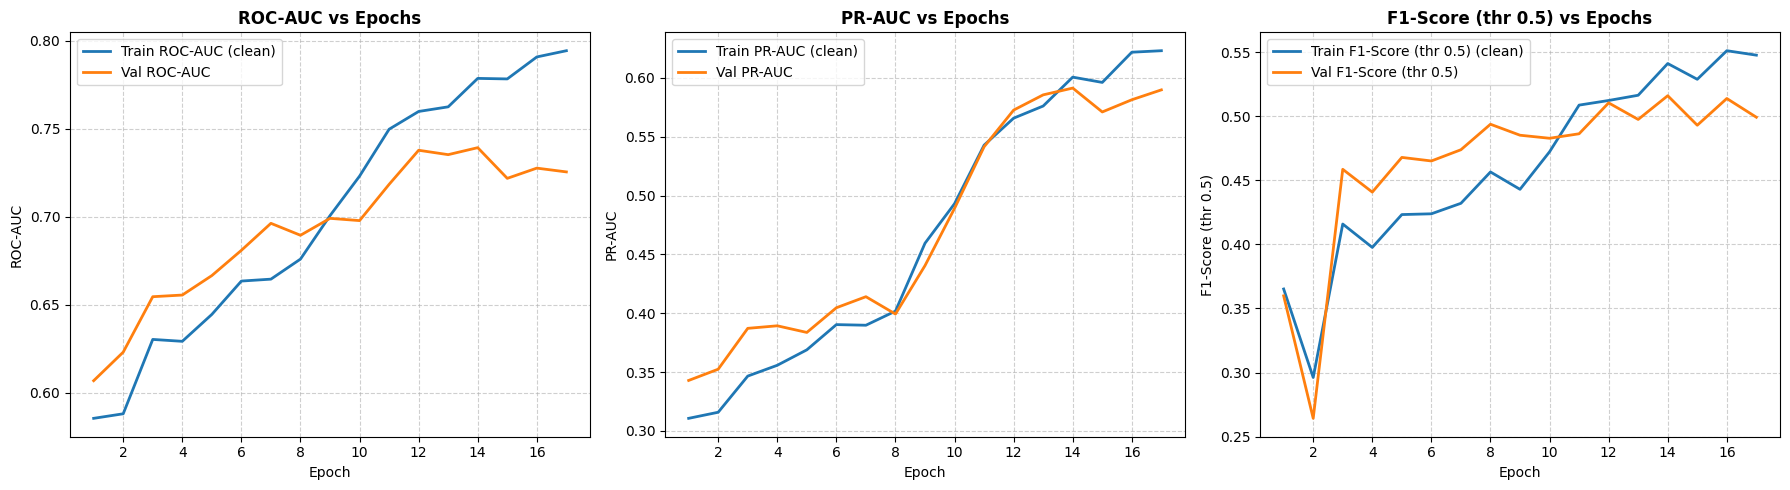

In [16]:
epochs = history['epoch']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (trnkey, valkey, name) in zip(axes, [
    ('trn_roc_auc', 'val_roc_auc', 'ROC-AUC'),
    ('trn_pr_auc',  'val_pr_auc',  'PR-AUC'),
    ('trn_f1',      'val_f1',      'F1-Score (thr 0.5)'),
]):
    ax.plot(epochs, history[trnkey], label=f'Train {name} (clean)', color='tab:blue', lw=2)
    ax.plot(epochs, history[valkey], label=f'Val {name}', color='tab:orange', lw=2)
    ax.set_title(f'{name} vs Epochs', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(name)
    ax.grid(True, linestyle='--', alpha=0.6); ax.legend()
plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'metrics_progression.png', dpi=300)
plt.show()

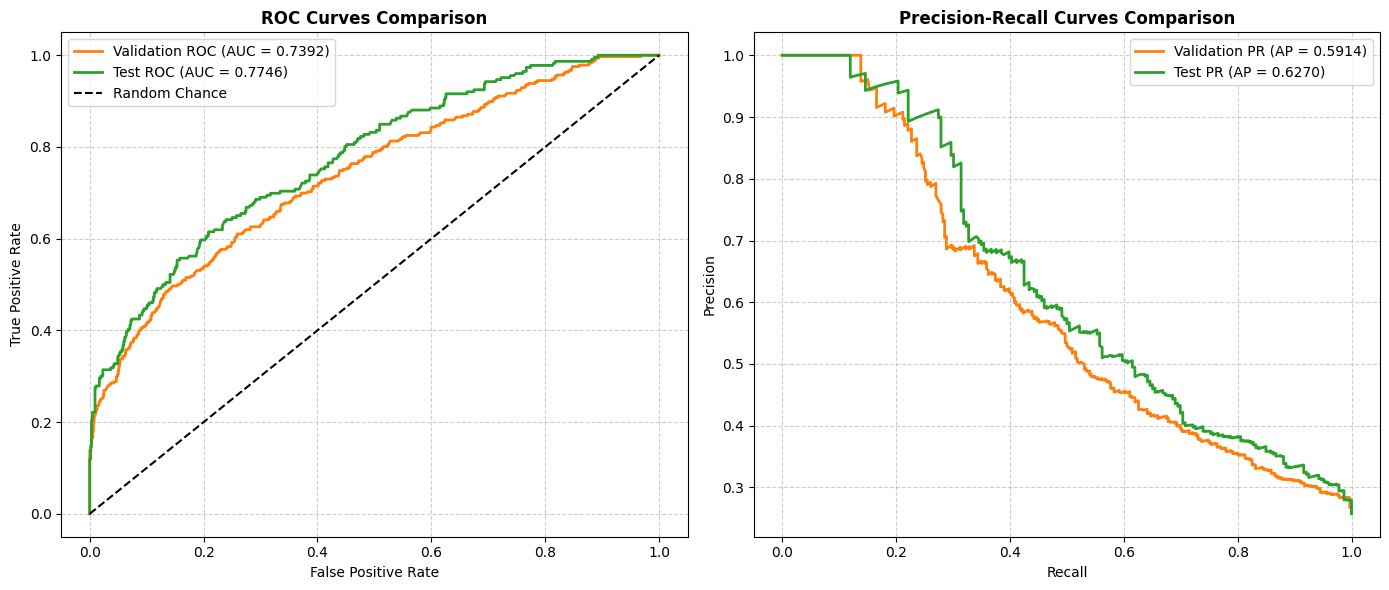

In [17]:
val_fpr, val_tpr, _ = roc_curve(vallabels, valpreds)
tst_fpr, tst_tpr, _ = roc_curve(testlabels, testpreds)
val_prec_c, val_rec_c, _ = precision_recall_curve(vallabels, valpreds)
tst_prec_c, tst_rec_c, _ = precision_recall_curve(testlabels, testpreds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(val_fpr, val_tpr, label=f'Validation ROC (AUC = {bestvalauc:.4f})', color='tab:orange', lw=2)
axes[0].plot(tst_fpr, tst_tpr, label=f'Test ROC (AUC = {tstauc:.4f})', color='tab:green', lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
axes[0].set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].grid(True, linestyle='--', alpha=0.6); axes[0].legend()

axes[1].plot(val_rec_c, val_prec_c, label=f'Validation PR (AP = {valprauc_best:.4f})', color='tab:orange', lw=2)
axes[1].plot(tst_rec_c, tst_prec_c, label=f'Test PR (AP = {tstprauc:.4f})', color='tab:green', lw=2)
axes[1].set_title('Precision-Recall Curves Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].grid(True, linestyle='--', alpha=0.6); axes[1].legend()

plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'roc_pr_curves_comparison.png', dpi=300)
plt.show()

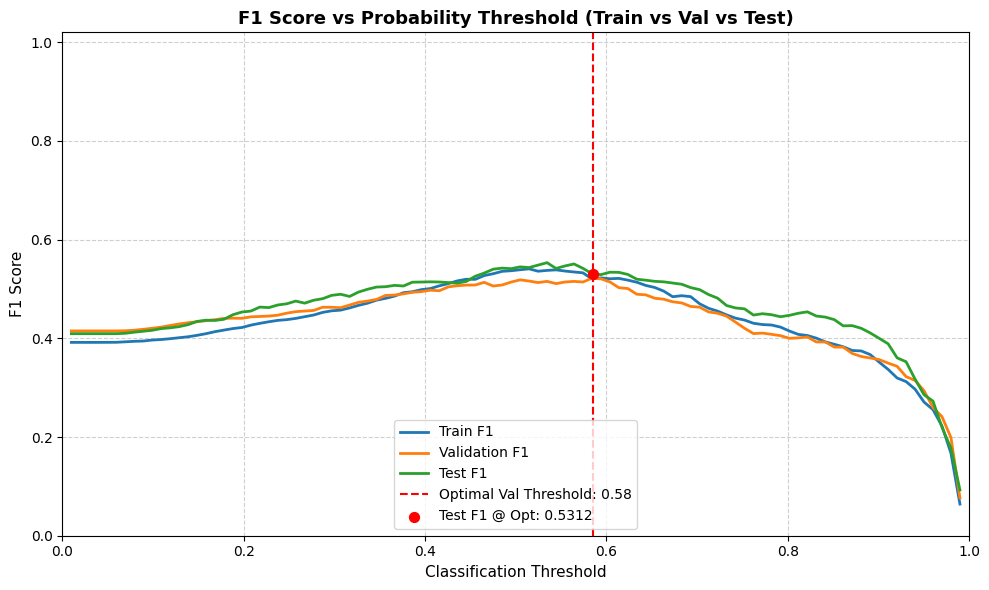

In [18]:
thresh_range = np.linspace(0.01, 0.99, 100)
trnpredsnp, valpredsnp = np.array(trnpreds), np.array(valpreds)
trn_f1_curve = [f1_score(trnlabels,  (trnpredsnp  >= t).astype(int), zero_division=0) for t in thresh_range]
val_f1_curve = [f1_score(vallabels,  (valpredsnp  >= t).astype(int), zero_division=0) for t in thresh_range]
tst_f1_curve = [f1_score(testlabels, (testpredsnp >= t).astype(int), zero_division=0) for t in thresh_range]

plt.figure(figsize=(10, 6))
plt.plot(thresh_range, trn_f1_curve, label='Train F1', color='tab:blue', lw=2)
plt.plot(thresh_range, val_f1_curve, label='Validation F1', color='tab:orange', lw=2)
plt.plot(thresh_range, tst_f1_curve, label='Test F1', color='tab:green', lw=2)
plt.axvline(x=bestthresh, color='red', linestyle='--', lw=1.5,
            label=f'Optimal Val Threshold: {bestthresh:.2f}')
test_f1_at_opt = f1_score(testlabelsnp, binopt, zero_division=0)
plt.scatter([bestthresh], [test_f1_at_opt], color='red', s=50, zorder=5,
            label=f'Test F1 @ Opt: {test_f1_at_opt:.4f}')
plt.title('F1 Score vs Probability Threshold (Train vs Val vs Test)', fontsize=13, fontweight='bold')
plt.xlabel('Classification Threshold', fontsize=11); plt.ylabel('F1 Score', fontsize=11)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.02])
plt.grid(True, linestyle='--', alpha=0.6); plt.legend(loc='lower center', fontsize=10)
plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / '3in1_f1_threshold_curve.png', dpi=300)
plt.show()

gc.collect()
torch.cuda.empty_cache()


  PERMUTATION TEST (H0: predictions independent of labels)
Permutations: 2000
Test class balance: 0.2574 positive (226/878)

Metric       Observed    Null mean     Null std    Z-score      p-value
----------------------------------------------------------------------
PR-AUC         0.6270       0.2625       0.0155     23.543     0.000500
ROC-AUC        0.7746       0.4995       0.0228     12.046     0.000500

  -> PR-AUC significantly better than chance (p < 0.001).
  -> ROC-AUC significantly better than chance (p < 0.001).


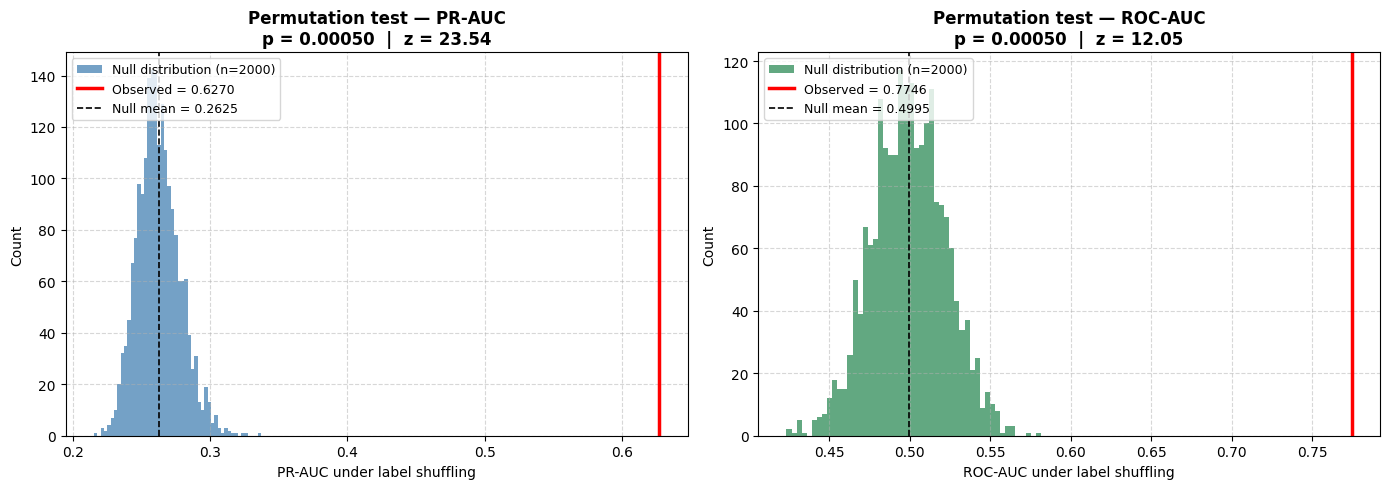

Saved: permutation_null_distributions.npz


In [19]:
# ==========================================
# PERMUTATION TEST — Is the model better than chance?
# ==========================================
# H0: predictions are independent of labels.
# Shuffle test labels N times, recompute metric, compare.
# p-value = fraction of null metrics >= observed.

print('\n' + '=' * 68)
print('  PERMUTATION TEST (H0: predictions independent of labels)')
print('=' * 68)

N_PERM = 2000
rng = np.random.default_rng(CFG.SEED)

testpredsnp  = np.asarray(testpreds,  dtype=np.float64)
testlabelsnp = np.asarray(testlabels, dtype=np.int64)

obs_pr  = average_precision_score(testlabelsnp, testpredsnp)
obs_roc = roc_auc_score(testlabelsnp, testpredsnp)

null_pr  = np.empty(N_PERM, dtype=np.float64)
null_roc = np.empty(N_PERM, dtype=np.float64)

for i in range(N_PERM):
    shuf = rng.permutation(testlabelsnp)
    if len(np.unique(shuf)) < 2:
        null_pr[i], null_roc[i] = 0.0, 0.5
        continue
    null_pr[i]  = average_precision_score(shuf, testpredsnp)
    null_roc[i] = roc_auc_score(shuf, testpredsnp)

# +1 correction so p is never exactly zero
p_pr  = (np.sum(null_pr  >= obs_pr)  + 1) / (N_PERM + 1)
p_roc = (np.sum(null_roc >= obs_roc) + 1) / (N_PERM + 1)

z_pr  = (obs_pr  - null_pr.mean())  / (null_pr.std()  + 1e-12)
z_roc = (obs_roc - null_roc.mean()) / (null_roc.std() + 1e-12)

print(f'Permutations: {N_PERM}')
print(f'Test class balance: {testlabelsnp.mean():.4f} positive '
      f'({testlabelsnp.sum()}/{len(testlabelsnp)})')
print()
print(f'{"Metric":<10} {"Observed":>10} {"Null mean":>12} {"Null std":>12} '
      f'{"Z-score":>10} {"p-value":>12}')
print('-' * 70)
print(f'{"PR-AUC":<10} {obs_pr:>10.4f} {null_pr.mean():>12.4f} '
      f'{null_pr.std():>12.4f} {z_pr:>10.3f} {p_pr:>12.6f}')
print(f'{"ROC-AUC":<10} {obs_roc:>10.4f} {null_roc.mean():>12.4f} '
      f'{null_roc.std():>12.4f} {z_roc:>10.3f} {p_roc:>12.6f}')
print()

if p_pr < 0.001:
    print('  -> PR-AUC significantly better than chance (p < 0.001).')
elif p_pr < 0.05:
    print('  -> PR-AUC significantly better than chance (p < 0.05).')
else:
    print('  -> PR-AUC NOT significant at p < 0.05.')

if p_roc < 0.001:
    print('  -> ROC-AUC significantly better than chance (p < 0.001).')
elif p_roc < 0.05:
    print('  -> ROC-AUC significantly better than chance (p < 0.05).')
else:
    print('  -> ROC-AUC NOT significant at p < 0.05.')

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(null_pr, bins=50, color='steelblue', alpha=0.75,
        label=f'Null distribution (n={N_PERM})')
ax.axvline(obs_pr, color='red', lw=2.5, label=f'Observed = {obs_pr:.4f}')
ax.axvline(null_pr.mean(), color='black', lw=1.2, ls='--',
           label=f'Null mean = {null_pr.mean():.4f}')
ax.set_title(f'Permutation test — PR-AUC\np = {p_pr:.5f}  |  z = {z_pr:.2f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('PR-AUC under label shuffling')
ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=9)

ax = axes[1]
ax.hist(null_roc, bins=50, color='seagreen', alpha=0.75,
        label=f'Null distribution (n={N_PERM})')
ax.axvline(obs_roc, color='red', lw=2.5, label=f'Observed = {obs_roc:.4f}')
ax.axvline(null_roc.mean(), color='black', lw=1.2, ls='--',
           label=f'Null mean = {null_roc.mean():.4f}')
ax.set_title(f'Permutation test — ROC-AUC\np = {p_roc:.5f}  |  z = {z_roc:.2f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('ROC-AUC under label shuffling')
ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'permutation_test.png', dpi=300)
plt.show()

np.savez(CFG.OUTPUTDIR / 'permutation_null_distributions.npz',
         null_pr=null_pr, null_roc=null_roc,
         obs_pr=obs_pr, obs_roc=obs_roc,
         p_pr=p_pr, p_roc=p_roc, n_perm=N_PERM)
print('Saved: permutation_null_distributions.npz')
print('=' * 68)


  BOOTSTRAP 95% CONFIDENCE INTERVALS (n=2000)
Metric          Point   Median               95% CI
----------------------------------------------------
ROC-AUC        0.7746   0.7750    [0.7388 – 0.8084]
PR-AUC         0.6270   0.6293    [0.5671 – 0.6844]
F1                  -   0.5310    [0.4742 – 0.5877]
Precision           -   0.5550    [0.4878 – 0.6230]
Recall              -   0.5088    [0.4444 – 0.5742]


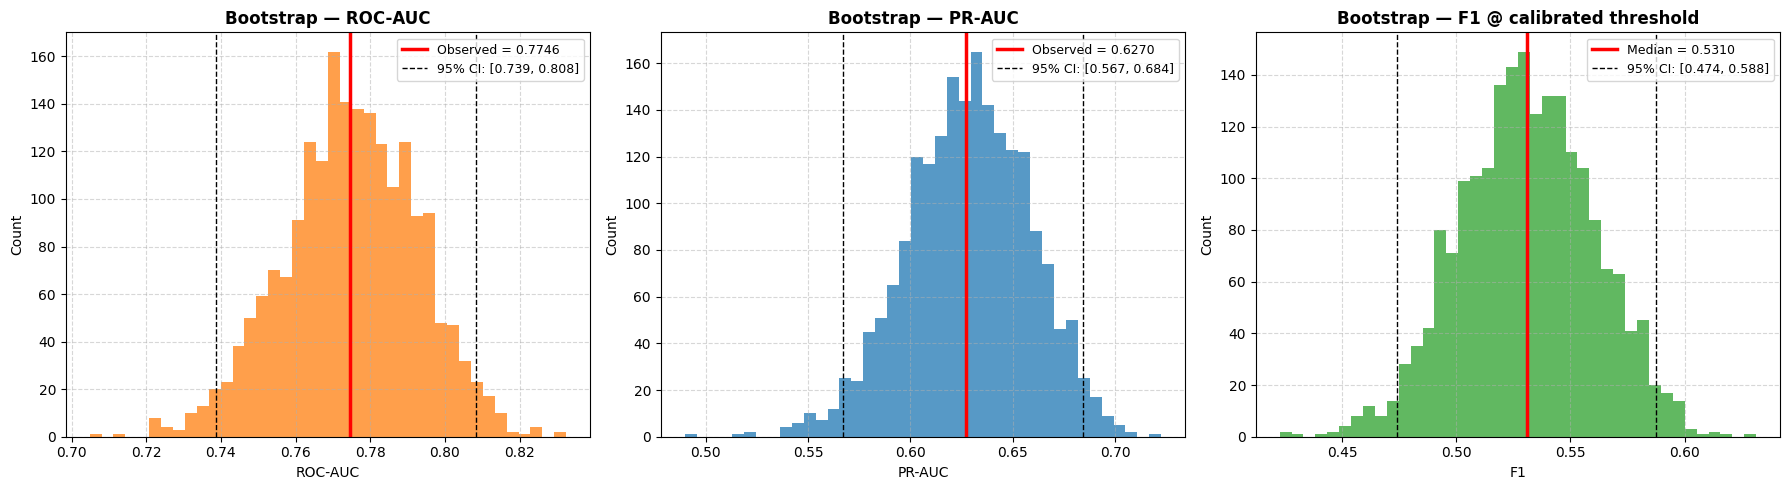

Saved: bootstrap_distributions.npz


In [20]:
# ==========================================
# BOOTSTRAP 95% CONFIDENCE INTERVALS
# ==========================================
# Resample the test set N times with replacement.
# Compute metric on each resample. Report the 2.5 / 50 / 97.5 quantiles.

def bootstrap_ci(y_true, y_pred, metric_fn, n=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n_samples = len(y_true)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)
        yt = y_true[idx]
        yp = y_pred[idx]
        if len(np.unique(yt)) < 2:
            continue
        scores.append(metric_fn(yt, yp))
    scores = np.array(scores)
    return (np.quantile(scores, alpha / 2),
            np.quantile(scores, 0.5),
            np.quantile(scores, 1 - alpha / 2),
            scores)

print('\n' + '=' * 68)
print('  BOOTSTRAP 95% CONFIDENCE INTERVALS (n=2000)')
print('=' * 68)

# --- Threshold-free metrics ---
lo_pr,  med_pr,  hi_pr,  pr_scores  = bootstrap_ci(testlabelsnp, testpredsnp, average_precision_score)
lo_roc, med_roc, hi_roc, roc_scores = bootstrap_ci(testlabelsnp, testpredsnp, roc_auc_score)

# --- F1 at calibrated threshold ---
def f1_at_thr(yt, yp):
    return f1_score(yt, (np.asarray(yp) >= bestthresh).astype(int), zero_division=0)

lo_f1, med_f1, hi_f1, f1_scores = bootstrap_ci(testlabelsnp, testpredsnp, f1_at_thr)

# --- Precision and Recall at calibrated threshold ---
def prec_at_thr(yt, yp):
    return precision_score(yt, (np.asarray(yp) >= bestthresh).astype(int), zero_division=0)

def rec_at_thr(yt, yp):
    return recall_score(yt, (np.asarray(yp) >= bestthresh).astype(int), zero_division=0)

lo_prec, med_prec, hi_prec, _ = bootstrap_ci(testlabelsnp, testpredsnp, prec_at_thr)
lo_rec,  med_rec,  hi_rec,  _ = bootstrap_ci(testlabelsnp, testpredsnp, rec_at_thr)

print(f'{"Metric":<12} {"Point":>8} {"Median":>8} {"95% CI":>20}')
print('-' * 52)
print(f'{"ROC-AUC":<12} {obs_roc:>8.4f} {med_roc:>8.4f} '
      f'   [{lo_roc:.4f} – {hi_roc:.4f}]')
print(f'{"PR-AUC":<12} {obs_pr:>8.4f} {med_pr:>8.4f} '
      f'   [{lo_pr:.4f} – {hi_pr:.4f}]')
print(f'{"F1":<12} {"-":>8} {med_f1:>8.4f} '
      f'   [{lo_f1:.4f} – {hi_f1:.4f}]')
print(f'{"Precision":<12} {"-":>8} {med_prec:>8.4f} '
      f'   [{lo_prec:.4f} – {hi_prec:.4f}]')
print(f'{"Recall":<12} {"-":>8} {med_rec:>8.4f} '
      f'   [{lo_rec:.4f} – {hi_rec:.4f}]')
print('=' * 68)

# ---------- Plots ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(roc_scores, bins=40, color='tab:orange', alpha=0.75)
ax.axvline(obs_roc, color='red', lw=2.5, label=f'Observed = {obs_roc:.4f}')
ax.axvline(lo_roc, color='black', lw=1, ls='--', label=f'95% CI: [{lo_roc:.3f}, {hi_roc:.3f}]')
ax.axvline(hi_roc, color='black', lw=1, ls='--')
ax.set_title('Bootstrap — ROC-AUC', fontweight='bold')
ax.set_xlabel('ROC-AUC'); ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5); ax.legend(fontsize=9)

ax = axes[1]
ax.hist(pr_scores, bins=40, color='tab:blue', alpha=0.75)
ax.axvline(obs_pr, color='red', lw=2.5, label=f'Observed = {obs_pr:.4f}')
ax.axvline(lo_pr, color='black', lw=1, ls='--', label=f'95% CI: [{lo_pr:.3f}, {hi_pr:.3f}]')
ax.axvline(hi_pr, color='black', lw=1, ls='--')
ax.set_title('Bootstrap — PR-AUC', fontweight='bold')
ax.set_xlabel('PR-AUC'); ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5); ax.legend(fontsize=9)

ax = axes[2]
ax.hist(f1_scores, bins=40, color='tab:green', alpha=0.75)
ax.axvline(med_f1, color='red', lw=2.5, label=f'Median = {med_f1:.4f}')
ax.axvline(lo_f1, color='black', lw=1, ls='--', label=f'95% CI: [{lo_f1:.3f}, {hi_f1:.3f}]')
ax.axvline(hi_f1, color='black', lw=1, ls='--')
ax.set_title('Bootstrap — F1 @ calibrated threshold', fontweight='bold')
ax.set_xlabel('F1'); ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'bootstrap_ci.png', dpi=300)
plt.show()

# Save arrays for the paper
np.savez(CFG.OUTPUTDIR / 'bootstrap_distributions.npz',
         pr_scores=pr_scores, roc_scores=roc_scores, f1_scores=f1_scores,
         obs_pr=obs_pr, obs_roc=obs_roc)
print('Saved: bootstrap_distributions.npz')

In [21]:
def train_one_run(df_train, df_val, df_test, run_seed=42, run_tag='lc'):
    """Full training run from scratch. Returns dict of metrics."""
    setseed(run_seed)

    # ---------- Cache ----------
    s_tr, l_tr, y_tr = buildrawcache(df_train, f'{run_tag}-tr')
    tr_cache = finalizecache(s_tr, l_tr, y_tr, LIDARMEAN, LIDARSTD)
    del s_tr, l_tr; gc.collect()

    s_v, l_v, y_v = buildrawcache(df_val, f'{run_tag}-va')
    va_cache = finalizecache(s_v, l_v, y_v, LIDARMEAN, LIDARSTD)
    del s_v, l_v; gc.collect()

    s_t, l_t, y_t = buildrawcache(df_test, f'{run_tag}-te')
    te_cache = finalizecache(s_t, l_t, y_t, LIDARMEAN, LIDARSTD)
    del s_t, l_t; gc.collect()

    # ---------- Sampler ----------
    cnt = df_train['label'].value_counts().to_dict()
    if cnt.get(0, 0) == 0 or cnt.get(1, 0) == 0:
        print(f'  [{run_tag}] SKIP — degenerate subset '
              f'(pos={cnt.get(1,0)}, neg={cnt.get(0,0)})')
        return {'run_tag': run_tag, 'error': 'degenerate',
                'n_train': len(df_train), 'frac': None}

    weights = [1.0 / cnt[lbl] for lbl in df_train['label']]
    smp = WeightedRandomSampler(weights=weights,
                                num_samples=len(df_train),
                                replacement=True)

    trn_ld    = DataLoader(MultiModalDataset(tr_cache, True),  batch_size=CFG.BATCHSIZE,
                           sampler=smp, num_workers=CFG.NUMWORKERS,
                           pin_memory=True, drop_last=True)
    trn_ld_ev = DataLoader(MultiModalDataset(tr_cache, False), batch_size=CFG.BATCHSIZE * 2,
                           shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
    va_ld     = DataLoader(MultiModalDataset(va_cache, False), batch_size=CFG.BATCHSIZE * 2,
                           shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
    te_ld     = DataLoader(MultiModalDataset(te_cache, False), batch_size=CFG.BATCHSIZE * 2,
                           shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)

    # ---------- Model / optim / sched / loss ----------
    mdl = createconvnextmodel(CFG.INCHANNELS, CFG.NUMCLASSES, CFG.DROPOUT).to(DEVICE)
    freezeearlystages(mdl, CFG.FREEZESTAGES)
    setbackbonefrozen(mdl, frozen=True)

    opt = optim.AdamW(buildparamgroups(mdl, CFG.BASELR, CFG.WEIGHTDECAY,
                                       CFG.HEADLRMULT, CFG.LLRD))
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max',
                                               factor=CFG.SCHED_FACTOR,
                                               patience=CFG.SCHED_PATIENCE,
                                               min_lr=1e-6)
    scl = torch.amp.GradScaler(device=DEVICE.type, enabled=CFG.USEAMP)

    pos_weight_t = None
    if CFG.USEPOSWEIGHT:
        pos_weight_t = torch.tensor([cnt.get(0, 1) / max(cnt.get(1, 1), 1)],
                                    dtype=torch.float32).to(DEVICE)
    crit = (FocalLoss(gamma=CFG.FOCALGAMMA, pos_weight=pos_weight_t)
            if CFG.USEFOCALLOSS else nn.BCEWithLogitsLoss(pos_weight=pos_weight_t))

    def _train_ep(m, ld, o, sc):
        m.train()
        tl, seen = 0.0, 0
        for x, y in ld:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            tgt = (y * (1 - CFG.LABELSMOOTH) + 0.5 * CFG.LABELSMOOTH) \
                  if CFG.LABELSMOOTH > 0 else y
            if CFG.MIXUPPROB > 0 and random.random() < CFG.MIXUPPROB:
                lam = float(np.random.beta(CFG.MIXUPALPHA, CFG.MIXUPALPHA))
                perm = torch.randperm(x.size(0), device=DEVICE)
                x = lam * x + (1 - lam) * x[perm]
                tgt = lam * tgt + (1 - lam) * tgt[perm]
            o.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
                lg = m(x).squeeze(1)
                ls = crit(lg, tgt)
            sc.scale(ls).backward()
            sc.unscale_(o)
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            sc.step(o)
            sc.update()
            tl += ls.item() * x.size(0)
            seen += x.size(0)
        return tl / max(seen, 1)

    @torch.no_grad()
    def _eval(m, ld):
        m.eval()
        tl, seen, ys, ps = 0.0, 0, [], []
        for x, y in ld:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
                lg = m(x).squeeze(1)
                ls = crit(lg, y)
            tl += ls.item() * x.size(0)
            seen += x.size(0)
            ps.extend(np.nan_to_num(torch.sigmoid(lg).float().cpu().numpy(),
                                    nan=0.5))
            ys.extend(y.cpu().numpy())
        return tl / max(seen, 1), ys, ps

    # ---------- Train ----------
    ckpt = CFG.OUTPUTDIR / f'{run_tag}_best.pth'
    best_auc = 0.0
    no_imp = 0
    frozen = True

    for ep in range(1, CFG.NUMEPOCHS + 1):
        if frozen and ep > CFG.FREEZEEPOCHS:
            setbackbonefrozen(mdl, frozen=False)
            frozen = False
            no_imp = 0

        _train_ep(mdl, trn_ld, opt, scl)
        _, vy, vp = _eval(mdl, va_ld)
        vauc = roc_auc_score(vy, vp) if len(set(vy)) > 1 else 0.0

        if not frozen:
            sch.step(vauc)

        if vauc > best_auc + CFG.MINDELTA:
            best_auc = vauc
            no_imp = 0
            torch.save(mdl.state_dict(), ckpt)
        else:
            if not frozen:
                no_imp += 1

        if ep % 5 == 0 or ep == 1:
            print(f'  [{run_tag}] ep {ep:02d} | '
                  f'val ROC-AUC {vauc:.4f} | best {best_auc:.4f}')

        if not frozen and no_imp >= CFG.PATIENCE:
            print(f'  [{run_tag}] early stop at ep {ep}')
            break

    # ---------- Final eval ----------
    mdl.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    mdl.eval()
    _, vy, vp = _eval(mdl, va_ld)
    _, ty, tp = _eval(mdl, te_ld)

    v_pr  = average_precision_score(vy, vp) if len(set(vy)) > 1 else 0.0
    v_roc = roc_auc_score(vy, vp)           if len(set(vy)) > 1 else 0.5
    t_pr  = average_precision_score(ty, tp) if len(set(ty)) > 1 else 0.0
    t_roc = roc_auc_score(ty, tp)           if len(set(ty)) > 1 else 0.5

    p_c, r_c, t_c = precision_recall_curve(vy, vp)
    f1c = 2 * (p_c[:-1] * r_c[:-1]) / (p_c[:-1] + r_c[:-1] + 1e-8)
    best_t = float(t_c[np.argmax(f1c)]) if len(t_c) else 0.5

    t_bin  = (np.array(tp) >= best_t).astype(int)
    t_f1   = f1_score(ty, t_bin, zero_division=0)
    t_prec = precision_score(ty, t_bin, zero_division=0)
    t_rec  = recall_score(ty, t_bin, zero_division=0)

    print(f'  [{run_tag}] DONE | n={len(df_train)} | '
          f'test PR-AUC={t_pr:.4f} ROC-AUC={t_roc:.4f} F1={t_f1:.4f}')

    return {
        'run_tag': run_tag,
        'n_train': len(df_train),
        'n_pos': int(df_train['label'].sum()),
        'n_neg': int((df_train['label'] == 0).sum()),
        'val_pr_auc': v_pr,
        'val_roc_auc': v_roc,
        'test_pr_auc': t_pr,
        'test_roc_auc': t_roc,
        'test_f1': t_f1,
        'test_precision': t_prec,
        'test_recall': t_rec,
        'threshold': best_t,
    }

In [22]:
# ============================================================
# PREDICT + SPLIT MONUMENTS  (no plot — just prepares data for v9 and 3D)
# Run after training / benchmark (needs model, CFG, LIDARMEAN, LIDARSTD, DEVICE)
# Creates: heatmap, monuments_detected, monuments_missed, MON_THRESHOLD
# Also saves a checkpoint so you never have to rerun the model.
# ============================================================

from pathlib import Path
import json, shutil
import numpy as np
import torch
import rasterio
import geopandas as gpd
from shapely.geometry import box

MONUMENTS_PATH = Path("/kaggle/input/datasets/shreyansdeshpande/monuments/monuments_inside_valid_dtm.gpkg")
MON_THRESHOLD  = round(float(bestthresh), 2) if "bestthresh" in globals() else 0.58
BATCH          = 32

# ---- 1. every patch (train + val + test) ------------------------------------
patch_files = []
for folder in [CFG.TRAINSITE, CFG.TRAINNOSITE, CFG.VALSITE, CFG.VALNOSITE, CFG.TESTSITE, CFG.TESTNOSITE]:
    if folder.exists():
        patch_files += sorted(folder.glob(f"*{CFG.IMGSUFFIX}"))
print(f"Patches: {len(patch_files):,}")

# ---- 2. same preprocessing as training --------------------------------------
rgb_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
rgb_std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def prep(path):
    with rasterio.open(path) as src:
        img = src.read(masked=True).astype(np.float32).filled(0.0)
        b = src.bounds
    sat = np.clip(img[CFG.SATBANDS] / CFG.SAT_SCALE, 0.0, 1.0)
    lid = (img[CFG.LIDARBANDS] - LIDARMEAN[:, None, None]) / (LIDARSTD[:, None, None] + 1e-6)
    lid = np.nan_to_num(np.clip(lid, -CFG.LIDARCLIP, CFG.LIDARCLIP), nan=0.0, posinf=0.0, neginf=0.0)
    x = torch.from_numpy(np.concatenate([sat, lid], 0).astype(np.float32))
    if CFG.IMAGENET_NORM:
        x[:3] = (x[:3] - rgb_mean) / rgb_std
    return x, box(b.left, b.bottom, b.right, b.top)

# ---- 3. predict (batched) ----------------------------------------------------
model.eval()
probs, geoms = [], []
with torch.no_grad():
    for s in range(0, len(patch_files), BATCH):
        xs, gs = zip(*[prep(p) for p in patch_files[s:s + BATCH]])
        xb = torch.stack(xs).to(DEVICE)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
            probs += torch.sigmoid(model(xb).squeeze(1)).float().cpu().tolist()
        geoms += gs
        if (s // BATCH) % 40 == 0:
            print(f"  {min(s + BATCH, len(patch_files)):,}/{len(patch_files):,}")

heatmap = gpd.GeoDataFrame({"filepath": [str(p) for p in patch_files], "probability": probs},
                           geometry=list(geoms), crs="EPSG:2157")
print(f"Predicted {len(heatmap):,} patches (mean p = {heatmap.probability.mean():.3f})")

# ---- 4. split monuments ------------------------------------------------------
if not MONUMENTS_PATH.exists():
    MONUMENTS_PATH = next(Path("/kaggle/input").rglob("monuments_inside_valid_dtm.gpkg"))
mons = gpd.read_file(MONUMENTS_PATH)
mons = mons.set_crs("EPSG:2157") if mons.crs is None else mons.to_crs("EPSG:2157")
mons = mons[mons.geometry.notna() & ~mons.geometry.is_empty].reset_index(drop=True)

tiles = heatmap.copy()
tiles["split"] = np.select([tiles.filepath.str.contains("/train/"), tiles.filepath.str.contains("/validation/"),
                            tiles.filepath.str.contains("/test/")], ["train", "val", "test"], "other")
pairs = gpd.sjoin(mons[["geometry"]], tiles, how="inner", predicate="intersects")
mons["max_prob"] = pairs.groupby(level=0)["probability"].max()
mons["max_prob_test"] = pairs[pairs.split == "test"].groupby(level=0)["probability"].max()

covered = mons["max_prob"].notna()
monuments_detected = mons[covered & (mons.max_prob >= MON_THRESHOLD)].copy()
monuments_missed   = mons[covered & (mons.max_prob <  MON_THRESHOLD)].copy()
t = mons["max_prob_test"].dropna()

print(f"\nMonuments: {len(mons):,}  |  threshold p ≥ {MON_THRESHOLD}")
print(f"  Detected: {len(monuments_detected):,}   Missed: {len(monuments_missed):,}   "
      f"Not on any patch: {int((~covered).sum()):,}")
print(f"  Recall (all patches):       {len(monuments_detected) / max(covered.sum(), 1):.1%}")
if len(t):
    print(f"  Recall (test patches only): {(t >= MON_THRESHOLD).mean():.1%}  ← honest number")

# ---- 5. checkpoint -----------------------------------------------------------
CK = Path("/kaggle/working/checkpoint"); CK.mkdir(parents=True, exist_ok=True)
if "ckptpath" in globals() and Path(ckptpath).exists():
    shutil.copy(ckptpath, CK / "convnext_tiny_multimodal_best.pth")
np.savez(CK / "lidar_stats.npz", mean=LIDARMEAN, std=LIDARSTD)
heatmap.to_file(CK / "heatmap_tiles.gpkg", driver="GPKG")
monuments_detected.to_file(CK / "monuments_detected.gpkg", driver="GPKG")
monuments_missed.to_file(CK / "monuments_missed.gpkg", driver="GPKG")
(CK / "settings.json").write_text(json.dumps({"MON_THRESHOLD": MON_THRESHOLD,
                                              "bestthresh": float(globals().get("bestthresh", 0.58))}))
print(f"\nCheckpoint saved to {CK} ✓  →  now run v9, then 3D")

Patches: 5,719
  32/5,719
  1,312/5,719
  2,592/5,719
  3,872/5,719
  5,152/5,719
Predicted 5,719 patches (mean p = 0.459)

Monuments: 1,182  |  threshold p ≥ 0.58
  Detected: 940   Missed: 205   Not on any patch: 37
  Recall (all patches):       82.1%
  Recall (test patches only): 78.5%  ← honest number

Checkpoint saved to /kaggle/working/checkpoint ✓  →  now run v9, then 3D


Calibrated on 1,245 validation patches (average model score 0.46 → real site rate 0.26)
High-probability zone: calibrated p ≥ 0.31  (model score ≥ 0.585)
Colour scale: transparent below 26% (average chance), darkest red at ≥ 48%

Accuracy on 183 TEST monuments (never seen in training):
                 zone   p ≥  % of area  % of test monuments  Kvamme gain
high-probability zone 0.309       30.2                 72.1         0.58
      top 10% of area 0.405       10.0                 33.9         0.70
      top 20% of area 0.348       20.0                 56.3         0.64
      top 30% of area 0.309       30.0                 72.1         0.58
Gain: 1 = perfect, 0 = no better than random, > 0.5 = useful predictive model

Candidate new sites: 66 zones of ≥ 2 patches (223 patches, 8.9 km²) with p ≥ 0.31 and no known monument within 100 m → candidate_new_sites.gpkg / .csv


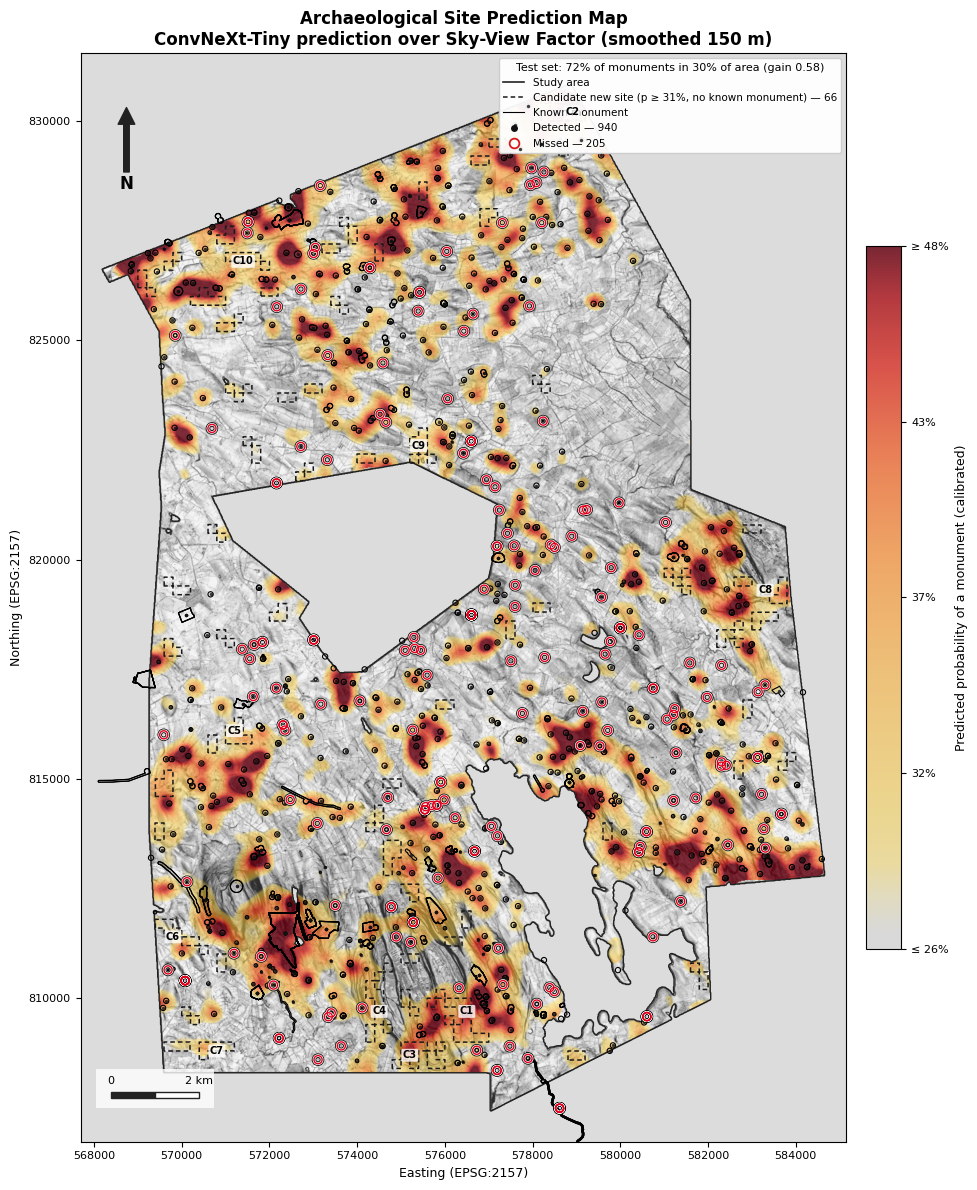

Saved: /kaggle/working/final_heatmap/prediction_map_v10.png


In [23]:
# ============================================================
# PREDICTION HEATMAP — v10
#   "Where are monuments likely to be?"  (the project's main result)
#   colour = model's CALIBRATED probability that a monument is there,
#            smoothed ~1 patch so neighbours share evidence
#   + known monuments on top (to check the map)
#   + candidate NEW sites (high probability, no recorded monument)
#   + accuracy on the TEST set (Kvamme's gain)
# Run AFTER "PREDICT + SPLIT MONUMENTS" (needs heatmap, monuments_detected,
# monuments_missed, MON_THRESHOLD). Run the 3D cell after this one to get
# the prediction map in 3D.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize, ListedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patches import PathPatch, Rectangle, Patch
from matplotlib.path import Path as MplPath
from scipy import ndimage as ndi
from shapely.geometry import box as shapely_box, shape as shapely_shape
from shapely.ops import unary_union
import rasterio
from rasterio.features import shapes as rasterio_shapes, rasterize, geometry_mask
from rasterio.enums import Resampling, MergeAlg
from rasterio.transform import from_origin
from sklearn.linear_model import LogisticRegression

# ============================================================
# PARAMETERS
# ============================================================
STUDY_AREA_PATH = "/kaggle/input/datasets/shreyansdeshpande/svfblabla/finaldtm_SVF_R16_D16.tif"
MONUMENTS_PATH  = "/kaggle/input/datasets/shreyansdeshpande/monuments/monuments_inside_valid_dtm.gpkg"

RESOLUTION_M = 20        # map grid
SMOOTH_M     = 150       # smoothing (≈ ¾ patch). 0 = raw patch squares, 250 = very soft
CALIBRATE    = True      # turn model scores into real probabilities (using validation patches)

P_LOW  = None            # below this probability: transparent (plain SVF).  None = average
                         #   chance of a patch holding a site (the "base rate")
P_HIGH = None            # at/above this: darkest red.  None = top 3 % of the area
HIGH_ZONE = None         # "high-probability zone" used for candidates + accuracy.
                         #   None = the model's validation-calibrated threshold

HAZE_ALPHA, CORE_ALPHA = 0.40, 0.82
SVF_LIGHTNESS = (0.18, 0.96)
SHOW_KNOWN    = True     # known monument outlines + detected/missed markers
SHOW_CANDIDATES = True   # dashed outlines around high-probability zones with no known monument
CANDIDATE_BUFFER_M = 100 # a zone counts as "new" if no known monument is within this distance
CANDIDATE_MIN_PATCHES = 2  # ignore isolated single high patches (usually noise)

OUTPUT_DIR = Path("/kaggle/working/final_heatmap"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TITLE = "Archaeological Site Prediction Map"


# ============================================================
# 1. PATCH PROBABILITIES + CALIBRATION
# ============================================================
tiles = heatmap[["geometry", "probability", "filepath"]].copy()
fp = tiles["filepath"].str.replace("\\\\", "/", regex=True)
tiles["split"] = np.select([fp.str.contains("/train/"), fp.str.contains("/validation/"),
                            fp.str.contains("/test/")], ["train", "val", "test"], "other")
tiles["label"] = np.where(fp.str.contains("/no_site/"), 0, np.where(fp.str.contains("/site/"), 1, -1))

val = tiles[(tiles.split == "val") & (tiles.label >= 0)]
logit = lambda p: np.log(np.clip(p, 1e-4, 1 - 1e-4) / (1 - np.clip(p, 1e-4, 1 - 1e-4)))
base_rate = float(val.label.mean()) if len(val) else float((tiles.label == 1).mean())

if CALIBRATE and len(val) > 50 and val.label.nunique() == 2:
    platt = LogisticRegression(C=1e6).fit(logit(val.probability.values)[:, None], val.label.values)
    calib = lambda p: platt.predict_proba(logit(np.asarray(p, float))[:, None])[:, 1]
    tiles["p"] = calib(tiles.probability.values)
    print(f"Calibrated on {len(val):,} validation patches "
          f"(average model score {val.probability.mean():.2f} → real site rate {base_rate:.2f})")
else:
    calib = lambda p: np.asarray(p, float)
    tiles["p"] = tiles.probability
    print("Calibration skipped — using raw model scores")

thr_raw = float(globals().get("bestthresh", MON_THRESHOLD))
HIGH = float(HIGH_ZONE) if HIGH_ZONE else float(calib([thr_raw])[0])
print(f"High-probability zone: calibrated p ≥ {HIGH:.2f}  (model score ≥ {thr_raw:.3f})")


# ============================================================
# 2. SVF BASEMAP + STUDY AREA  (same handling as v9)
# ============================================================
with rasterio.open(STUDY_AREA_PATH) as src:
    rb, rh, rw = src.bounds, src.height, src.width
    dec = max(1, int(np.ceil(max(rh, rw) / 2500)))
    oh, ow = max(1, rh // dec), max(1, rw // dec)
    svf = src.read(1, out_shape=(oh, ow), resampling=Resampling.bilinear,
                   masked=True).astype(np.float32).filled(np.nan)
    valid = src.dataset_mask(out_shape=(oh, ow)) > 0
    raw = src.read(1, out_shape=(oh, ow), resampling=Resampling.nearest)
    t = src.transform * src.transform.scale(rw / ow, rh / oh)
    raster_crs = src.crs or "EPSG:2157"
edge = np.r_[raw[0], raw[-1], raw[:, 0], raw[:, -1]]; edge = edge[np.isfinite(edge)]
if edge.size:
    vals, cnts = np.unique(edge, return_counts=True)
    if cnts.max() > 0.5 * edge.size:
        filled = np.isclose(raw, vals[cnts.argmax()]) & valid
        if filled.mean() > 0.01:
            valid &= ~filled; svf[filled] = np.nan
valid = ndi.binary_closing(ndi.binary_opening(valid, iterations=1), iterations=2)
px_ = abs(t.a)
polys = [shapely_shape(g) for g, v in rasterio_shapes(valid.astype(np.uint8), transform=t) if v == 1]
polys = [p for p in polys if p.area > 0.05e6]
merged_geom = (unary_union(polys).buffer(px_).buffer(-px_).simplify(px_ / 2) if polys
               else shapely_box(rb.left, rb.bottom, rb.right, rb.top))
study_area = gpd.GeoSeries([merged_geom], crs=raster_crs).to_crs(tiles.crs)
merged_geom = study_area.iloc[0].buffer(0)
vv = svf[np.isfinite(svf)]
svf_vmin, svf_vmax = np.percentile(vv, 2), np.percentile(vv, 98)
svf_cmap = LinearSegmentedColormap.from_list("svf", [str(SVF_LIGHTNESS[0]), str(SVF_LIGHTNESS[1])])


# ============================================================
# 3. PROBABILITY SURFACE  (patches → grid → smooth)
# ============================================================
pad = max(3 * SMOOTH_M, 400)
minx, miny, maxx, maxy = study_area.total_bounds
minx -= pad; miny -= pad; maxx += pad; maxy += pad
nx = int(np.ceil((maxx - minx) / RESOLUTION_M)); ny = int(np.ceil((maxy - miny) / RESOLUTION_M))
x_edges = minx + np.arange(nx + 1) * RESOLUTION_M
y_edges = miny + np.arange(ny + 1) * RESOLUTION_M
gt = from_origin(minx, maxy, RESOLUTION_M, RESOLUTION_M)

psum = rasterize(zip(tiles.geometry, tiles.p), out_shape=(ny, nx), transform=gt,
                 fill=0, merge_alg=MergeAlg.add, dtype="float32")
pcnt = rasterize(((g, 1.0) for g in tiles.geometry), out_shape=(ny, nx), transform=gt,
                 fill=0, merge_alg=MergeAlg.add, dtype="float32")
psum, pcnt = np.flipud(psum), np.flipud(pcnt)          # → south-up like the other maps
covered = pcnt > 0
if SMOOTH_M > 0:                                        # normalised smoothing: no edge darkening
    s = SMOOTH_M / RESOLUTION_M
    num = ndi.gaussian_filter(np.where(covered, psum / np.maximum(pcnt, 1), 0), s)
    den = ndi.gaussian_filter(covered.astype("float32"), s)
    prob = np.where(den > 0.25, num / np.maximum(den, 1e-6), np.nan)
else:
    prob = np.where(covered, psum / np.maximum(pcnt, 1), np.nan)

in_area = np.flipud(~geometry_mask([merged_geom], out_shape=(ny, nx), transform=gt))
prob[~in_area] = np.nan
ok = np.isfinite(prob)
lo = float(P_LOW) if P_LOW is not None else base_rate
hi = float(P_HIGH) if P_HIGH is not None else float(np.percentile(prob[ok], 97))
hi = max(hi, lo + 0.05)
value = np.clip((np.nan_to_num(prob, nan=0) - lo) / (hi - lo), 0, 1)   # 0–1 colour value
print(f"Colour scale: transparent below {lo:.0%} (average chance), darkest red at ≥ {hi:.0%}")


# ============================================================
# 4. ACCURACY ON THE TEST SET  (Kvamme's gain)
# ============================================================
known = gpd.read_file(MONUMENTS_PATH) if Path(MONUMENTS_PATH).exists() else \
        gpd.GeoDataFrame(geometry=list(monuments_detected.geometry) + list(monuments_missed.geometry),
                         crs=monuments_detected.crs)
known = known.set_crs(tiles.crs) if known.crs is None else known.to_crs(tiles.crs)
known = known[known.geometry.notna() & ~known.geometry.is_empty].reset_index(drop=True)

cent = gpd.GeoDataFrame(geometry=known.geometry.representative_point(), crs=tiles.crs)
test_tiles = tiles[tiles.split == "test"]
test_mon = gpd.sjoin(cent, test_tiles[["geometry"]], how="inner", predicate="within")
test_mon = test_mon[~test_mon.index.duplicated()]
ci = np.clip(((test_mon.geometry.x - minx) / RESOLUTION_M).astype(int), 0, nx - 1)
ri = np.clip(((test_mon.geometry.y - miny) / RESOLUTION_M).astype(int), 0, ny - 1)
site_p = prob[ri, ci]; site_p = site_p[np.isfinite(site_p)]

def gain_row(name, level):
    area = float((prob[ok] >= level).mean())
    sites = float((site_p >= level).mean()) if site_p.size else np.nan
    g = 1 - area / sites if sites and sites > 0 else np.nan
    return {"zone": name, "p ≥": round(level, 3), "% of area": round(100 * area, 1),
            "% of test monuments": round(100 * sites, 1), "Kvamme gain": round(g, 2)}

rows = [gain_row("high-probability zone", HIGH)]
for pct in (10, 20, 30):                                  # top X % of the area
    rows.append(gain_row(f"top {pct}% of area", float(np.percentile(prob[ok], 100 - pct))))
gain_table = pd.DataFrame(rows)
print(f"\nAccuracy on {len(site_p)} TEST monuments (never seen in training):")
print(gain_table.to_string(index=False))
print("Gain: 1 = perfect, 0 = no better than random, > 0.5 = useful predictive model")
gain_table.to_csv(OUTPUT_DIR / "prediction_map_accuracy.csv", index=False)


# ============================================================
# 5. CANDIDATE NEW SITES  (high probability, no known monument nearby)
# ============================================================
hi_tiles = tiles[tiles.p >= HIGH]
near_known = gpd.sjoin(hi_tiles, gpd.GeoDataFrame(geometry=known.buffer(CANDIDATE_BUFFER_M),
                                                  crs=tiles.crs), how="inner", predicate="intersects")
cand_tiles = hi_tiles[~hi_tiles.index.isin(near_known.index)]
if len(cand_tiles):
    zones = gpd.GeoDataFrame(geometry=[cand_tiles.buffer(1).union_all() if hasattr(cand_tiles, "union_all")
                                       else cand_tiles.buffer(1).unary_union], crs=tiles.crs)
    zones = zones.explode(index_parts=False).reset_index(drop=True)
    zones["geometry"] = zones.buffer(-1)
    j = gpd.sjoin(cand_tiles[["geometry", "p"]], zones.reset_index().rename(columns={"index": "zone_id"}),
                  how="inner", predicate="intersects")
    stats = j.groupby("zone_id")["p"].agg(["max", "mean", "count"])
    zones["max_p"] = stats["max"].round(3); zones["mean_p"] = stats["mean"].round(3)
    zones["n_patches"] = stats["count"]; zones["area_km2"] = (zones.area / 1e6).round(3)
    zones["score"] = (zones["n_patches"] * zones["mean_p"]).round(2)       # size × strength
    zones = zones[zones["n_patches"] >= CANDIDATE_MIN_PATCHES]
    zones = zones.sort_values("score", ascending=False).reset_index(drop=True)
    zones["candidate"] = [f"C{i + 1}" for i in range(len(zones))]
    zones.to_file(OUTPUT_DIR / "candidate_new_sites.gpkg", driver="GPKG")
    zc = zones.copy(); zc["easting"] = zc.centroid.x.round(0); zc["northing"] = zc.centroid.y.round(0)
    zc.drop(columns="geometry").to_csv(OUTPUT_DIR / "candidate_new_sites.csv", index=False)
    print(f"\nCandidate new sites: {len(zones)} zones of ≥ {CANDIDATE_MIN_PATCHES} patches "
          f"({int(zones.n_patches.sum()) if len(zones) else 0} patches, "
          f"{zones.area_km2.sum():.1f} km²) with p ≥ {HIGH:.2f} and no known monument within "
          f"{CANDIDATE_BUFFER_M} m → candidate_new_sites.gpkg / .csv")
else:
    zones = gpd.GeoDataFrame(geometry=[], crs=tiles.crs)
    print("\nNo candidate new sites at this threshold.")


# ============================================================
# 6. COLOURS  (warm only)
# ============================================================
glow_cmap = LinearSegmentedColormap.from_list("warm", [
    (0.00, "#ffe97a"), (0.20, "#ffd23f"), (0.38, "#fdb030"), (0.55, "#fb8a24"),
    (0.70, "#f05a1e"), (0.83, "#d8261b"), (0.93, "#a80f16"), (1.00, "#650010")])
MIN_SHOW = 0.02
rgba = glow_cmap(value)
fade = np.clip((value - MIN_SHOW) / (0.12 - MIN_SHOW), 0, 1)
rgba[..., 3] = np.where(ok, fade * (HAZE_ALPHA + (CORE_ALPHA - HAZE_ALPHA) * value), 0)


# ============================================================
# 7. FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(11, 12))
fig.patch.set_facecolor("white"); ax.set_facecolor("#dcdcdc")
svf_img = ax.imshow(svf, extent=[rb.left, rb.right, rb.bottom, rb.top], origin="upper",
                    cmap=svf_cmap, vmin=svf_vmin, vmax=svf_vmax, interpolation="bilinear", zorder=0)
heat_img = ax.imshow(rgba, extent=[minx, maxx, miny, maxy], origin="lower",
                     interpolation="bilinear", zorder=1)
study_area.boundary.plot(ax=ax, color="#222", linewidth=1.0, zorder=3)

def _poly_path(geom):
    polys_ = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    verts, codes = [], []
    for p in polys_:
        for ring in [p.exterior, *p.interiors]:
            xy = np.asarray(ring.coords); verts.extend(xy)
            codes.extend([MplPath.MOVETO] + [MplPath.LINETO] * (len(xy) - 2) + [MplPath.CLOSEPOLY])
    return MplPath(verts, codes)
clip_patch = PathPatch(_poly_path(merged_geom), transform=ax.transData, facecolor="none", edgecolor="none")
ax.add_patch(clip_patch); heat_img.set_clip_path(clip_patch); svf_img.set_clip_path(clip_patch)

if SHOW_CANDIDATES and len(zones):
    zones.boundary.plot(ax=ax, color="#1a1a1a", linewidth=1.1, linestyle=(0, (3, 2)), zorder=4)
    for _, zr in zones.head(10).iterrows():                     # label the 10 strongest
        c = zr.geometry.representative_point()
        ax.text(c.x, c.y, zr.candidate, fontsize=7, fontweight="bold", ha="center", va="center",
                zorder=9, bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

if SHOW_KNOWN:
    kt = known.geom_type
    known[kt.isin(["Polygon", "MultiPolygon"])].boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=5)
    if kt.isin(["LineString", "MultiLineString"]).any():
        known[kt.isin(["LineString", "MultiLineString"])].plot(ax=ax, color="black", linewidth=1.1, zorder=5)
    dp = monuments_detected.geometry.centroid; mp = monuments_missed.geometry.centroid
    ax.scatter(dp.x, dp.y, s=6, c="#111", linewidths=0, alpha=0.8, zorder=6)
    ax.scatter(mp.x, mp.y, s=34, facecolors="none", edgecolors="#111", linewidths=3.2, zorder=7)
    ax.scatter(mp.x, mp.y, s=34, facecolors="none", edgecolors="white", linewidths=2.0, zorder=7)
    ax.scatter(mp.x, mp.y, s=34, facecolors="none", edgecolors="#e0001b", linewidths=1.0, zorder=8)

# colour bar in probability units, fading to grey at the low end like the map
t_ = np.linspace(0, 1, 256)
a_ = np.clip((t_ - MIN_SHOW) / (0.12 - MIN_SHOW), 0, 1) * (HAZE_ALPHA + (CORE_ALPHA - HAZE_ALPHA) * t_)
bar = glow_cmap(t_)[:, :3] * a_[:, None] + np.array([0.85, 0.85, 0.85]) * (1 - a_[:, None])
cbar = fig.colorbar(ScalarMappable(norm=Normalize(0, 1), cmap=ListedColormap(bar)),
                    ax=ax, fraction=0.035, pad=0.02)
ticks = np.linspace(0, 1, 5)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"≤ {lo:.0%}"] + [f"{lo + v * (hi - lo):.0%}" for v in ticks[1:-1]] + [f"≥ {hi:.0%}"])
cbar.set_label("Predicted probability of a monument" + (" (calibrated)" if CALIBRATE else ""), fontsize=9)
cbar.ax.tick_params(labelsize=8)

hz = gain_table.iloc[0]
handles = [Line2D([0], [0], color="#222", lw=1.2, label="Study area")]
if SHOW_CANDIDATES and len(zones):
    handles.append(Line2D([0], [0], color="#1a1a1a", lw=1.1, linestyle=(0, (3, 2)),
                          label=f"Candidate new site (p ≥ {HIGH:.0%}, no known monument) — {len(zones)}"))
if SHOW_KNOWN:
    handles += [Line2D([0], [0], color="black", lw=0.8, label="Known monument"),
                Line2D([0], [0], marker="o", color="none", markerfacecolor="#111", markeredgecolor="none",
                       markersize=5, label=f"Detected — {len(monuments_detected)}"),
                Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor="#d7191c",
                       markeredgewidth=1.3, markersize=7, label=f"Missed — {len(monuments_missed)}")]
ax.legend(handles=handles, loc="upper right", fontsize=7.5, framealpha=0.95,
          title=(f"Test set: {hz['% of test monuments']:.0f}% of monuments in "
                 f"{hz['% of area']:.0f}% of area (gain {hz['Kvamme gain']:.2f})"), title_fontsize=8)

sxmin, symin, sxmax, symax = study_area.total_bounds
pxm, pym = 0.03 * (sxmax - sxmin), 0.03 * (symax - symin)
ax.set_xlim(sxmin - pxm, sxmax + pxm); ax.set_ylim(symin - pym, symax + pym); ax.set_aspect("equal")
x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim(); span = x1 - x0
barlen = [1000, 2000, 5000, 10000][int(np.argmin(np.abs(np.array([1000, 2000, 5000, 10000]) - span / 5)))]
bx, by, bh = x0 + 0.04 * span, y0 + 0.04 * (y1 - y0), 0.006 * (y1 - y0)
ax.add_patch(Rectangle((bx - 0.02 * span, by - 1.5 * bh), barlen + 0.04 * span, 6 * bh,
                       facecolor="white", edgecolor="none", alpha=0.8, zorder=6.5))
ax.add_patch(Rectangle((bx, by), barlen / 2, bh, facecolor="#222", edgecolor="#222", zorder=7))
ax.add_patch(Rectangle((bx + barlen / 2, by), barlen / 2, bh, facecolor="white", edgecolor="#222", zorder=7))
ax.text(bx, by + 2.2 * bh, "0", ha="center", fontsize=8, zorder=7)
ax.text(bx + barlen, by + 2.2 * bh, f"{barlen / 1000:g} km", ha="center", fontsize=8, zorder=7)
ax.annotate("N", xy=(x0 + 0.06 * span, y1 - 0.05 * (y1 - y0)), xytext=(x0 + 0.06 * span, y1 - 0.12 * (y1 - y0)),
            ha="center", va="center", fontsize=12, fontweight="bold", zorder=7,
            arrowprops=dict(facecolor="#222", edgecolor="#222", width=4, headwidth=12))
ax.set_title(f"{TITLE}\nConvNeXt-Tiny prediction over Sky-View Factor (smoothed {SMOOTH_M} m)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Easting (EPSG:2157)", fontsize=9); ax.set_ylabel("Northing (EPSG:2157)", fontsize=9)
ax.tick_params(labelsize=8); ax.ticklabel_format(style="plain", useOffset=False)
plt.tight_layout()
png_path = OUTPUT_DIR / "prediction_map_v10.png"
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {png_path}")


# ============================================================
# 8. HAND OVER TO THE 3D CELL  (3D will now show this prediction surface)
# ============================================================
density_km2 = np.clip((np.nan_to_num(prob, nan=0) - lo) / (hi - lo), 0, None).astype("float32")
# (not capped at 1 → the strongest areas still rise above the rest in 3D)
vmax, GAMMA = 1.0, 1.0
MAP_CBAR_LABEL = "Predicted probability of a monument"
MAP_TICKTEXT = [f"≤ {lo:.0%}", f"{(lo + hi) / 2:.0%}", f"≥ {hi:.0%}"]
MAP_SUBTITLE = "Height & colour = predicted probability of a monument  ·  ground = DTM with Sky-View Factor shading"

3D grid: 785 × 553 at 30 m
  dtm_dchg005 (1).tif: fill value 0.0 treated as no data
DTM files: 1
Trimmed to DTM coverage: 241.9 → 241.9 km²
Elevation 6–356 m | slope p95 13.1°
Terrain relief 350 m drawn ×0.6; red threshold 1.0/km² = 520 m spike
  Hotspot 1: E 581493, N 813236 — 4 monuments within 500 m
  Hotspot 2: E 576243, N 812876 — 7 monuments within 500 m
  Hotspot 3: E 574803, N 827216 — 5 monuments within 500 m
  Hotspot 4: E 568743, N 826826 — 4 monuments within 500 m
  Hotspot 5: E 572553, N 828026 — 15 monuments within 500 m
  Hotspot 6: E 576843, N 810026 — 14 monuments within 500 m
Interactive mesh: 68,124 vertices, 133,824 triangles


Saved interactive view: /kaggle/working/final_heatmap/density_3d_interactive.html


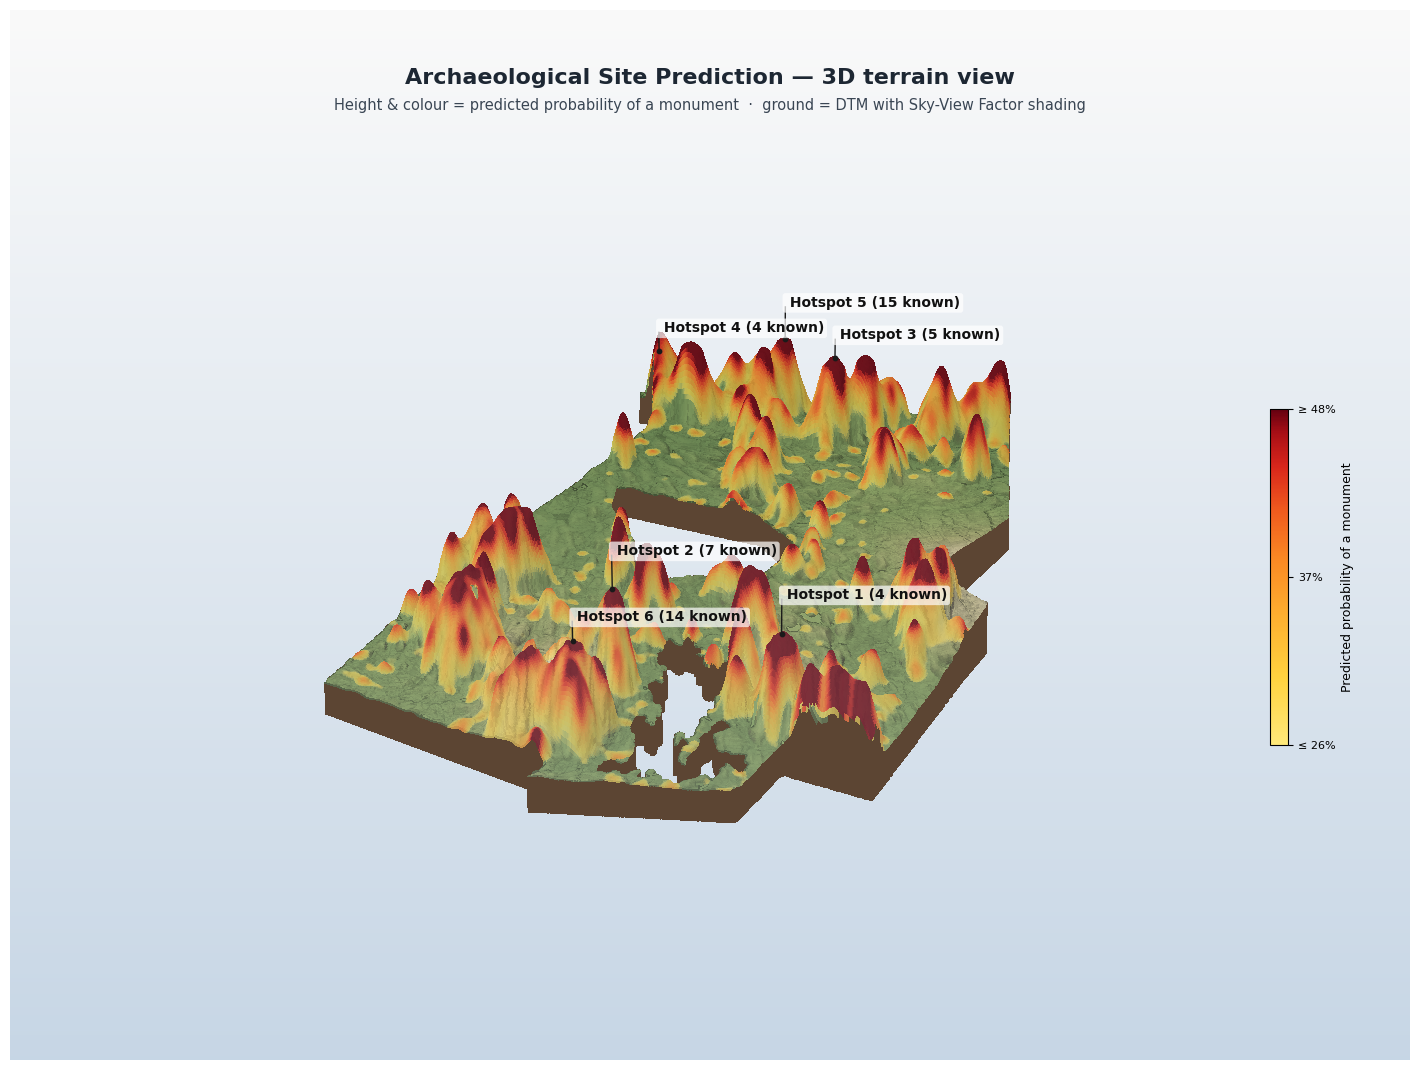

Saved static view: /kaggle/working/final_heatmap/density_3d_realistic.png


In [24]:
# ============================================================
# 3D DENSITY MAP v3 — matches the v9 2D "glow" heatmap
#   ground  = real DTM, textured with SVF (ambient occlusion) + multi-direction
#             hillshade + elevation/slope colours
#   overlay = the same glow colours as v9 (whatever COLOR_SCHEME v9 uses)
#   spikes  = monument density (red threshold of v9 = full spike height)
#
# Run AFTER the v9 2D cell (reuses density_km2, x_edges, y_edges, vmax, GAMMA,
# glow_cmap, MIN_SHOW, HAZE_ALPHA, CORE_ALPHA, merged_geom, STUDY_AREA_PATH,
# monuments_detected, monuments_missed)
# ============================================================

from pathlib import Path
import numpy as np
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.features import geometry_mask
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import plotly.graph_objects as go


# ============================================================
# PARAMETERS
# ============================================================
DTM_DIR    = Path("/kaggle/input/datasets/shreyansdeshpande/dtmfile1234")  # folder or file
SVF_PATH   = STUDY_AREA_PATH      # same SVF as the 2D map (ground texture)
SLOPE_PATH = None                 # optional slope raster (degrees). None = computed from DTM

RES_3D_M        = 30     # static PNG grid (25–40). Smaller = sharper, slower
PLOTLY_RES_M    = 50     # interactive grid (40–60). Smaller = sharper, bigger HTML

# ---- Heights ----------------------------------------------------------------
SPIKE_HEIGHT_M  = 520    # height where v9 turns red (= "full" hotspot)
HEIGHT_SMOOTH_M = 220    # extra smoothing of the HEIGHT only (colours stay sharp).
                         #   Bigger = broad rolling hills, 0 = sharp columns
HEIGHT_GAMMA    = 1.3    # >1 = only real clusters rise, <1 = medium areas rise more
TOP_PEAK_BOOST  = 0.35   # how far the densest cores may rise above full height
RISE_FROM       = 0.12   # colour level (0–1) where the ground starts to lift.
                         #   Below it the glow is draped flat on the terrain
TERRAIN_RELIEF_M = 220   # drawn height of the real terrain (auto exaggeration)
BASE_DEPTH_M    = 180    # thickness of the block base

# ---- Realism ----------------------------------------------------------------
SVF_STRENGTH    = 0.45   # how strongly SVF darkens hollows/ditches (0–0.7)
ROCK_SLOPE_DEG  = (10, 28)  # slopes in this range blend to a rocky tint
ATMOS_HAZE      = 0.22   # distance haze on the far side of the static image (0 = off)
GLOW_ALPHA_BOOST = 1.1   # >1 = stronger glow colours on the 3D surface

# ---- Labels / markers -------------------------------------------------------
N_HOTSPOT_LABELS  = 6
HOTSPOT_MIN_SEP_M = 1500
SHOW_MISSED_3D    = True

VIEW_ELEV, VIEW_AZIM = 32, -58     # static camera

OUTPUT_DIR = Path("/kaggle/working/final_heatmap")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def smoothstep(e0, e1, x):
    t = np.clip((x - e0) / (e1 - e0), 0, 1)
    return t * t * (3 - 2 * t)


# ============================================================
# 1. 3D GRID  (cropped to the study area)
# ============================================================
crs = monuments_detected.crs
bx0, by0, bx1, by1 = merged_geom.bounds
res = float(RES_3D_M)
gx0, gy0 = bx0 - 2 * res, by0 - 2 * res
nx3 = int(np.ceil((bx1 - bx0) / res)) + 4
ny3 = int(np.ceil((by1 - by0) / res)) + 4
xc = gx0 + (np.arange(nx3) + 0.5) * res
yc = gy0 + (np.arange(ny3) + 0.5) * res
grid_transform = from_origin(gx0, gy0 + ny3 * res, res, res)
print(f"3D grid: {ny3} × {nx3} at {res:.0f} m")

def clean_mask(m):
    """close tiny gaps, fill small holes, drop tiny islands"""
    m = ndi.binary_closing(m, iterations=2)
    holes, n_h = ndi.label(~m)
    if n_h:
        sizes = ndi.sum(np.ones_like(holes), holes, range(1, n_h + 1))
        border = set(np.unique(np.r_[holes[0], holes[-1], holes[:, 0], holes[:, -1]]))
        m |= np.isin(holes, [i + 1 for i, s in enumerate(sizes)
                             if s * res * res < 0.25e6 and (i + 1) not in border])
    isl, n_i = ndi.label(m)
    if n_i > 1:
        sizes = ndi.sum(np.ones_like(isl), isl, range(1, n_i + 1))
        m &= np.isin(isl, [i + 1 for i, s in enumerate(sizes) if s * res * res >= 0.1e6])
    return m

inside = clean_mask(np.flipud(~geometry_mask([merged_geom], out_shape=(ny3, nx3),
                                             transform=grid_transform, all_touched=False)))


# ============================================================
# 2. READ RASTERS ONTO THE GRID  (tiles / any CRS / downsampled on read)
# ============================================================
def read_to_grid(paths, lo=-1e30, hi=1e30, how=Resampling.average):
    paths = [Path(p) for p in (paths if isinstance(paths, (list, tuple)) else [paths])]
    files = []
    for p in paths:
        files += ([p] if p.is_file() else
                  sorted({q for e in ("*.tif", "*.tiff", "*.TIF", "*.vrt", "*.img") for q in p.rglob(e)}))
    acc = np.zeros((ny3, nx3)); cnt = np.zeros((ny3, nx3))
    for f in files:
        with rasterio.open(f) as src:
            nod = src.nodata
            if nod is None:   # no nodata set → look for a constant fill along the raster edge
                sm = src.read(1, out_shape=(max(1, src.height // 20), max(1, src.width // 20)),
                              resampling=Resampling.nearest)
                e = np.r_[sm[0], sm[-1], sm[:, 0], sm[:, -1]]
                vals, cnts = np.unique(e, return_counts=True)
                nod = float(vals[cnts.argmax()]) if cnts.max() > 0.5 * e.size else -9999
                if nod != -9999:
                    print(f"  {Path(f).name}: fill value {nod} treated as no data")
            with WarpedVRT(src, crs=crs, transform=grid_transform, width=nx3, height=ny3,
                           resampling=how, src_nodata=nod, nodata=np.nan, dtype="float32") as vrt:
                a = np.flipud(vrt.read(1).astype("float64"))
        a[(a < lo) | (a > hi)] = np.nan
        ok = np.isfinite(a); acc[ok] += a[ok]; cnt[ok] += 1
    out = np.where(cnt > 0, acc / np.maximum(cnt, 1), np.nan)
    return out, len(files)

def fill_gaps(a, fallback):
    gaps = ~np.isfinite(a)
    if not gaps.any():
        return a
    w = ndi.gaussian_filter(np.where(gaps, 0, 1.0), 3)
    v = ndi.gaussian_filter(np.where(gaps, 0, a), 3)
    return np.where(gaps, np.where(w > 0.02, v / np.maximum(w, 1e-9), fallback), a)

dtm, n_dtm = read_to_grid(DTM_DIR, -500, 9000)
print(f"DTM files: {n_dtm}")

# A constant value covering lots of cells (e.g. 0 around the survey) = fill, not terrain
fin = dtm[np.isfinite(dtm)]
if fin.size:
    vals, cnts = np.unique(fin, return_counts=True)
    if cnts.max() > 0.05 * fin.size:
        print(f"DTM fill value detected: {vals[cnts.argmax()]} → treated as no data")
        dtm[dtm == vals[cnts.argmax()]] = np.nan

# Trim the study area to where the DTM really has data (removes flat "empty" land)
TRIM_TO_DTM = True
dtm_ok = np.isfinite(dtm)
if TRIM_TO_DTM and (dtm_ok & inside).sum() > 0.2 * inside.sum():
    before = inside.sum()
    inside = clean_mask(inside & ndi.binary_closing(dtm_ok, iterations=2))
    print(f"Trimmed to DTM coverage: {before * res * res / 1e6:.1f} → "
          f"{inside.sum() * res * res / 1e6:.1f} km²")
if not np.isfinite(dtm[inside]).any():
    print("⚠ DTM does not cover the study area — flat ground used")
    dtm = np.zeros((ny3, nx3))
dtm = fill_gaps(dtm, np.nanmedian(dtm[inside]))

svf3, _ = read_to_grid(SVF_PATH, -10, 10)
svf3 = fill_gaps(svf3, np.nanmedian(svf3[inside]) if np.isfinite(svf3[inside]).any() else 1.0)
s_lo, s_hi = np.nanpercentile(svf3[inside], [2, 98])
svf_n = np.clip((svf3 - s_lo) / max(s_hi - s_lo, 1e-9), 0, 1)

if SLOPE_PATH:
    slope, _ = read_to_grid(SLOPE_PATH, 0, 90)
    slope = fill_gaps(slope, 0)
else:
    gy_, gx_ = np.gradient(dtm, res)
    slope = np.degrees(np.arctan(np.hypot(gx_, gy_)))
print(f"Elevation {dtm[inside].min():.0f}–{dtm[inside].max():.0f} m | "
      f"slope p95 {np.percentile(slope[inside], 95):.1f}°")


# ============================================================
# 3. DENSITY ON THE 3D GRID  (resampled from the v9 density)
# ============================================================
r2 = RESOLUTION_M
YY, XX = np.meshgrid(yc, xc, indexing="ij")
rows = (YY - y_edges[0]) / r2 - 0.5
cols = (XX - x_edges[0]) / r2 - 0.5
dens = ndi.map_coordinates(density_km2, [rows, cols], order=1, mode="constant", cval=0)

dn = dens / vmax                                   # 1.0 = where v9 turns red
nd = np.clip(dn, 0, 1) ** GAMMA                    # same colour value as v9


# ============================================================
# 4. HEIGHTS
# ============================================================
relief = max(np.ptp(dtm[inside]), 1.0)
exag = TERRAIN_RELIEF_M / relief
ground = (dtm - dtm[inside].min()) * exag

dn_h = dn if HEIGHT_SMOOTH_M <= 0 else ndi.gaussian_filter(dn, HEIGHT_SMOOTH_M / res)
dn_h = dn_h * (dn.max() / max(dn_h.max(), 1e-9)) ** 0.5   # keep top peaks tall after smoothing
dn_soft = dn_h.copy()
dn_soft[dn_h > 1] = 1 + TOP_PEAK_BOOST * np.log(dn_h[dn_h > 1])
lift = smoothstep(RISE_FROM, RISE_FROM + 0.3, np.clip(dn_h, 0, 1) ** GAMMA)
spikes = SPIKE_HEIGHT_M * np.power(np.clip(dn_soft, 0, None), HEIGHT_GAMMA) * lift
Z = ground + spikes
print(f"Terrain relief {relief:.0f} m drawn ×{exag:.1f}; red threshold {vmax:.1f}/km² = "
      f"{SPIKE_HEIGHT_M} m spike")


# ============================================================
# 5. REALISTIC COLOURS
# ============================================================
# 5a. ground: elevation tint → rocky on steep slopes
hyps = LinearSegmentedColormap.from_list(
    "hyps", ["#5d7a4a", "#7f9459", "#a3a46c", "#bfb58c", "#d8d0b6"])
el = (dtm - dtm[inside].min()) / relief
ground_rgb = hyps(np.clip(el, 0, 1))[..., :3]
rock = np.array([0.55, 0.49, 0.43])
rk = smoothstep(ROCK_SLOPE_DEG[0], ROCK_SLOPE_DEG[1], slope)[..., None] * 0.6
ground_rgb = ground_rgb * (1 - rk) + rock * rk

# 5b. SVF = ambient occlusion (hollows, ditches, banks read like the 2D map)
ao = (1 - SVF_STRENGTH) + SVF_STRENGTH * svf_n

# 5c. multi-direction hillshade (softer, more natural than one light)
def multi_hs(surface, exag_=1.0):
    out = np.zeros_like(surface)
    for az, wgt in [(315, 0.4), (270, 0.2), (0, 0.2), (225, 0.2)]:
        out += wgt * LightSource(azdeg=az, altdeg=40).hillshade(
            surface, vert_exag=exag_, dx=res, dy=res)
    return out
hs_terrain = multi_hs(dtm, max(exag, 1) * 2)
hs_spikes = LightSource(azdeg=315, altdeg=38).hillshade(Z, dx=res, dy=res)
shade = 0.55 * hs_terrain + 0.45 * hs_spikes

base_rgb = ground_rgb * ao[..., None] * (0.45 + 0.75 * shade[..., None])

# 5d. v9 glow overlay (same colours + opacity ramp as the 2D map)
glow = glow_cmap(nd)[..., :3] * (0.62 + 0.5 * shade[..., None])
fade_in = np.clip((nd - MIN_SHOW) / (0.12 - MIN_SHOW), 0, 1)
ga = np.clip(fade_in * (HAZE_ALPHA + (CORE_ALPHA - HAZE_ALPHA) * nd) * GLOW_ALPHA_BOOST, 0, 1)
rgb = np.clip(base_rgb * (1 - ga[..., None]) + glow * ga[..., None], 0, 1)


# ============================================================
# 6. HOTSPOTS
# ============================================================
hotspots = []
if N_HOTSPOT_LABELS > 0:
    peaks = (dens == ndi.maximum_filter(dens, size=5)) & inside & (dn > 0.5)
    iy, ix = np.where(peaks)
    chosen = []
    for o in np.argsort(dens[iy, ix])[::-1]:
        px_, py_ = xc[ix[o]], yc[iy[o]]
        if all(np.hypot(px_ - a, py_ - b) >= HOTSPOT_MIN_SEP_M for a, b, _ in chosen):
            chosen.append((px_, py_, o))
        if len(chosen) == N_HOTSPOT_LABELS:
            break
    _pred = "MAP_CBAR_LABEL" in globals() and vmax == 1.0          # v10 prediction map → count all known
    _mons = (list(monuments_detected.geometry.centroid) + list(monuments_missed.geometry.centroid)
             if _pred else list(monuments_detected.geometry.centroid))
    mxy = np.array([[p_.x, p_.y] for p_ in _mons]) if _mons else np.zeros((0, 2))
    for rank, (px_, py_, o) in enumerate(chosen, 1):
        hotspots.append(dict(name=f"Hotspot {rank}", x=px_, y=py_, z=Z[iy[o], ix[o]],
                             n=int((np.hypot(mxy[:, 0] - px_, mxy[:, 1] - py_) < 500).sum())))
    for r, h in enumerate(sorted(hotspots, key=lambda h: h["x"])):
        h["lift"] = 0.20 + 0.14 * (r % 2)
    for h in hotspots:
        print(f"  {h['name']}: E {h['x']:.0f}, N {h['y']:.0f} — {h['n']} monuments within 500 m")


def surface_z_at(px_, py_):
    j = np.clip(((np.asarray(px_) - gx0) / res).astype(int), 0, nx3 - 1)
    i = np.clip(((np.asarray(py_) - gy0) / res).astype(int), 0, ny3 - 1)
    return Z[i, j]


# ============================================================
# 7. BLOCK BASE  (ring of cells outside the area dropped to a floor)
# ============================================================
floor_z = -BASE_DEPTH_M
ring = ndi.binary_dilation(inside) & ~inside
Z_draw = np.where(inside, Z, np.where(ring, floor_z, np.nan))
wall = ring.copy()
wall[:-1, :] |= ring[1:, :]; wall[:, :-1] |= ring[:, 1:]; wall[:-1, :-1] |= ring[1:, 1:]
wall_rgb = np.array([0.36, 0.27, 0.20])
rgb_draw = np.where(wall[..., None], wall_rgb, rgb)

span_x, span_y = xc[-1] - xc[0], yc[-1] - yc[0]
z_top = np.nanmax(Z_draw)


# Labels: prediction map (v10) if it ran last, otherwise monument density (v9)
IS_PRED   = "MAP_CBAR_LABEL" in globals() and globals().get("GAMMA", 0.85) == 1.0 and vmax == 1.0
CB_LABEL  = MAP_CBAR_LABEL if IS_PRED else "Detected monuments per km²"
CB_TICKS  = MAP_TICKTEXT if IS_PRED else ["0", f"{vmax * 0.5 ** (1 / GAMMA):.1f}", f"≥ {vmax:.1f}"]
MAIN_TITLE = ("Archaeological Site Prediction — 3D terrain view" if IS_PRED
              else "Archaeological Monument Density — 3D terrain view")
SUB_TITLE = (MAP_SUBTITLE if IS_PRED else
             "Height & colour = density of detected monuments  ·  ground = DTM with Sky-View Factor shading")
HS_WORD   = "known" if IS_PRED else ""
hs_note = lambda h: ((f"{h['n']} known" if h["n"] else "no known site") if IS_PRED else f"{h['n']}")

# ============================================================
# 8. INTERACTIVE 3D  (Plotly mesh with true per-vertex colours)
# ============================================================
st = max(1, int(round(PLOTLY_RES_M / res)))
Zs, Cs = Z_draw[::st, ::st], rgb_draw[::st, ::st]
xs, ys = xc[::st], yc[::st]
valid = np.isfinite(Zs)
idx = -np.ones(Zs.shape, dtype=np.int64)
idx[valid] = np.arange(valid.sum())
VX, VY = np.meshgrid(xs, ys)
a_, b_, c_, d_ = idx[:-1, :-1], idx[:-1, 1:], idx[1:, :-1], idx[1:, 1:]
q = (a_ >= 0) & (b_ >= 0) & (c_ >= 0) & (d_ >= 0)
I = np.r_[a_[q], b_[q]]; J = np.r_[b_[q], d_[q]]; K = np.r_[c_[q], c_[q]]
vcol = ["#%02x%02x%02x" % tuple(c) for c in (np.clip(Cs[valid], 0, 1) * 255).astype(int)]
print(f"Interactive mesh: {valid.sum():,} vertices, {len(I):,} triangles")

fig3d = go.Figure()
fig3d.add_trace(go.Mesh3d(
    x=VX[valid], y=VY[valid], z=Zs[valid], i=I, j=J, k=K, vertexcolor=vcol,
    flatshading=False, hoverinfo="skip", name="Surface",
    lighting=dict(ambient=0.8, diffuse=0.35, specular=0.05, roughness=0.95),
    lightposition=dict(x=-5e4, y=5e4, z=8e4)))
# colour bar (dummy trace) matching the 2D map
fig3d.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None], mode="markers", showlegend=False, hoverinfo="skip",
    marker=dict(color=[0], cmin=0, cmax=1, showscale=True,
                colorscale=[[t, "#%02x%02x%02x" % tuple(int(255 * v) for v in glow_cmap(t)[:3])]
                            for t in np.linspace(0, 1, 11)],
                colorbar=dict(title=dict(text=CB_LABEL, side="right"), len=0.55,
                              tickvals=[0, 0.5, 1],
                              ticktext=CB_TICKS))))
if SHOW_MISSED_3D and len(monuments_missed):
    mc = monuments_missed.geometry.centroid
    fig3d.add_trace(go.Scatter3d(x=mc.x, y=mc.y, z=surface_z_at(mc.x, mc.y) + 20, mode="markers",
                                 marker=dict(size=2.5, color="#d7191c"), visible="legendonly",
                                 name=f"Missed monuments ({len(monuments_missed)})"))
dc = monuments_detected.geometry.centroid
fig3d.add_trace(go.Scatter3d(x=dc.x, y=dc.y, z=surface_z_at(dc.x, dc.y) + 20, mode="markers",
                             marker=dict(size=2, color="#111"), visible="legendonly",
                             name=f"Detected monuments ({len(monuments_detected)})"))
for h in hotspots:
    fig3d.add_trace(go.Scatter3d(
        x=[h["x"]] * 2, y=[h["y"]] * 2, z=[h["z"], h["z"] + h["lift"] * z_top],
        mode="lines+text", line=dict(color="#222", width=2), hoverinfo="skip", showlegend=False,
        text=["", f"<b>{h['name']}</b> ({hs_note(h)})"], textposition="top center",
        textfont=dict(size=11, color="#111")))
fig3d.update_layout(
    title=MAIN_TITLE,
    width=1150, height=820, margin=dict(l=0, r=0, t=50, b=0),
    paper_bgcolor="#e9eef2", legend=dict(x=0.01, y=0.97, bgcolor="rgba(255,255,255,0.8)"),
    scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False),
               bgcolor="#e9eef2", aspectmode="manual",
               aspectratio=dict(x=span_x / max(span_x, span_y), y=span_y / max(span_x, span_y), z=0.22),
               camera=dict(eye=dict(x=0.7, y=-1.25, z=0.75))))
html_path = OUTPUT_DIR / "density_3d_interactive.html"
fig3d.write_html(html_path, include_plotlyjs=True)
fig3d.show()
print(f"Saved interactive view: {html_path}")


# ============================================================
# 9. STATIC RENDER  (matplotlib, sky backdrop + distance haze)
# ============================================================
sky = np.array([0.86, 0.90, 0.94])
if ATMOS_HAZE > 0:
    az = np.radians(VIEW_AZIM)
    depth = (XX - XX.mean()) * np.cos(az) + (YY - YY.mean()) * np.sin(az)   # toward the back
    depth = (depth - depth.min()) / max(np.ptp(depth), 1)
    hz = (ATMOS_HAZE * depth ** 1.5)[..., None]
    rgb_static = np.where(wall[..., None], rgb_draw, rgb_draw * (1 - hz) + sky * hz)
else:
    rgb_static = rgb_draw

fig = plt.figure(figsize=(14, 10.5))
bg = fig.add_axes([0, 0, 1, 1], zorder=-1)
grad = np.linspace(0, 1, 256)[:, None]
bg.imshow(np.dstack([0.78 + 0.2 * grad, 0.84 + 0.14 * grad, 0.90 + 0.08 * grad]) * np.ones((1, 2, 1)),
          aspect="auto", extent=[0, 1, 0, 1], origin="lower")
bg.set_axis_off()

ax3 = fig.add_subplot(111, projection="3d", computed_zorder=False)
ax3.set_facecolor((0, 0, 0, 0))
X3, Y3 = np.meshgrid(xc, yc)
ax3.plot_surface(X3, Y3, Z_draw, facecolors=rgb_static, rstride=1, cstride=1,
                 linewidth=0, antialiased=False, shade=False, zorder=1)
for h in hotspots:
    top = h["z"] + h["lift"] * z_top
    ax3.plot([h["x"]] * 2, [h["y"]] * 2, [h["z"], top], color="#1a1a1a", lw=1.0, zorder=10)
    ax3.scatter([h["x"]], [h["y"]], [h["z"]], s=10, c="#1a1a1a", zorder=10, depthshade=False)
    ax3.text(h["x"], h["y"], top, f" {h['name']} ({hs_note(h)})", fontsize=10, fontweight="bold",
             color="#111", zorder=11,
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7))
ax3.set_box_aspect((span_x, span_y, 0.22 * max(span_x, span_y)), zoom=1.4)
ax3.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)
ax3.set_axis_off()

fig.text(0.5, 0.93, MAIN_TITLE,
         ha="center", fontsize=16, fontweight="bold", color="#1d2733")
fig.text(0.5, 0.905, SUB_TITLE,
         ha="center", fontsize=10.5, color="#3a4654")
cax = fig.add_axes([0.9, 0.3, 0.013, 0.32])
cb = fig.colorbar(ScalarMappable(norm=Normalize(0, 1), cmap=glow_cmap), cax=cax)
cb.set_ticks([0, 0.5, 1])
cb.set_ticklabels(CB_TICKS)
cb.set_label(CB_LABEL, fontsize=9)
cb.ax.tick_params(labelsize=8)

png3d = OUTPUT_DIR / "density_3d_realistic.png"
plt.savefig(png3d, dpi=250, bbox_inches="tight")
plt.show()
print(f"Saved static view: {png3d}")